# Notebook 2: Minimal characterization of HPA configurations

## Overview of the minimal version

This minimal version of Notebook 2 gathers the analyses needed to characterize Horizontal Pod Autoscaler (HPA) configurations from the data already mined in Notebook 1. It keeps a lighter flow for execution on Google Colab, leaving out the exploratory analyses of the full version.

The notebook covers four main groups of analysis:

1. the distribution of HPA API versions and its evolution over time;
2. the structural richness of the configurations, through the HPA Feature Richness Score (HFRS);
3. the adoption of specific capabilities, such as `spec.behavior`, `memory` metrics, custom metrics, and `minReplicas >= 2`;
4. configuration smells, such as very low CPU thresholds, `minReplicas = maxReplicas`, use of legacy versions, and recurring configuration profiles.

This version assumes that the `data/` folder already holds the CSV files produced by the earlier pipeline stages, or that the bootstrap can download and extract `data.zip`. The section texts avoid fixing long numeric conclusions in the markdown; the values should be read from the `print` output and the figures produced by the corresponding cells.

**A note on terminology.** The term *feature richness* describes the extent to which an HPA configuration uses the expressive capabilities of the specification. It does not imply that richer configurations are necessarily better, more correct, or more suitable for a given workload.


## 0. Google Colab bootstrap

This section prepares the notebook for execution on Google Colab and keeps compatibility with a local run in VS Code or Jupyter.

When running on Colab, the notebook uses the temporary environment of the session itself by default:

```text
/content/hpa
```

That path does not depend on the Google Drive account of the original project. The required files are downloaded from the archived release of the artifact on Zenodo, and from the GitHub repository as a fallback, including `requirements.txt`, `data.zip` and, when needed, `repos_history.zip`.

The bootstrap performs the following tasks:

1. detects whether the notebook is running on Google Colab or locally;
2. sets the project root to `/content/hpa` on Colab, or to the current directory in a local run;
3. creates the minimal directory structure of the project;
4. downloads `requirements.txt` when the file is not available locally;
5. installs the required dependencies;
6. downloads and extracts `data.zip` when the main CSV files are missing;
7. extracts `data/repos_history.zip` into `data/repos_history` when needed;
8. validates the main files before moving on to the analyses.

To store outputs persistently on Google Drive, set `HPA_PROJECT_DIR` before running this cell:

```python
import os
os.environ["HPA_PROJECT_DIR"] = "/content/drive/MyDrive/Colab Notebooks/hpa"
```

Otherwise the notebook runs under `/content/hpa`, which Colab recreates on every new session.


In [1]:
# ============================================================
# Google Colab bootstrap, compatible with local VSCode/Jupyter
# ============================================================

import os
import sys
import subprocess
import zipfile
import shutil
from pathlib import Path
from urllib.request import urlretrieve

IN_COLAB = "google.colab" in sys.modules

# Where the bootstrap downloads data.zip and repos_history.zip when they are not
# already present, which is the case in a fresh Google Colab runtime. A local run
# from the archived package needs no download, because data/ ships with it.
#
# The archived release on Zenodo is the reference source. Set HPA_ARTIFACT_BASE_URL
# to override it, for example to test against the development repository:
#
#     os.environ["HPA_ARTIFACT_BASE_URL"] = "https://raw.githubusercontent.com/CallyCa/hpa_usage/main"
#
# Zenodo file URLs follow https://zenodo.org/records/<RECORD_ID>/files/<name>
ZENODO_BASE_URL = "https://zenodo.org/records/XXXXXXX/files"
GITHUB_BASE_URL = "https://raw.githubusercontent.com/CallyCa/hpa_usage/main"

BASE_URL = os.environ.get("HPA_ARTIFACT_BASE_URL", ZENODO_BASE_URL).rstrip("/")

DATA_ZIP_URL = f"{BASE_URL}/data.zip"
REPOS_HISTORY_ZIP_URL = f"{BASE_URL}/repos_history.zip"
REQUIREMENTS_URL = f"{BASE_URL}/requirements.txt"

# You may override this path before running the cell, for example:
# os.environ["HPA_PROJECT_DIR"] = "/content/hpa"
if IN_COLAB:
    # Option A, use temporary Colab storage, faster but not persistent after runtime reset.
    DEFAULT_PROJECT_DIR = Path("/content/hpa")

    # Option B, uncomment this if you want outputs persisted in Google Drive.
    # from google.colab import drive
    # try:
    #     drive.mount("/content/drive")
    # except Exception:
    #     drive.mount("/content/drive", force_remount=True)
    # DEFAULT_PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/hpa")
else:
    DEFAULT_PROJECT_DIR = Path.cwd()

PROJECT_DIR = Path(os.environ.get("HPA_PROJECT_DIR", str(DEFAULT_PROJECT_DIR))).expanduser()
DATA_DIR = PROJECT_DIR / "data"
REPOS_HIST_DIR = DATA_DIR / "repos_history"
PLOTS_DIR = DATA_DIR / "figures" / "notebook-2"


def _safe_mkdir(path: Path) -> None:
    try:
        path.mkdir(parents=True, exist_ok=True)
    except OSError as exc:
        raise OSError(
            f"Could not create/access {path}. "
            "If this is Google Colab with Drive mounted, the Drive mount may be stale. "
            "Use Runtime > Restart runtime, run the bootstrap again, and approve the Drive mount."
        ) from exc


for _p in [PROJECT_DIR, DATA_DIR]:
    _safe_mkdir(_p)

try:
    os.chdir(PROJECT_DIR)
except OSError as exc:
    raise OSError(
        f"Could not switch to PROJECT_DIR={PROJECT_DIR}. "
        "If this is Google Colab with Drive mounted, restart the runtime and rerun this bootstrap cell."
    ) from exc

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print(f"Running in Colab: {IN_COLAB}")
print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory:    {DATA_DIR}")


def _pip_install(*packages: str) -> None:
    if not packages:
        return
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)


def _download_file(url: str, output_file: Path, description: str) -> bool:
    """Download a file, falling back to the development repository.

    The archived release on Zenodo is tried first. While that record does not
    exist yet, or if it is unreachable, the GitHub mirror is used instead, so a
    fresh Colab runtime still works.
    """
    output_file.parent.mkdir(parents=True, exist_ok=True)

    candidates = [url]
    if url.startswith(ZENODO_BASE_URL):
        candidates.append(url.replace(ZENODO_BASE_URL, GITHUB_BASE_URL))

    for candidate in candidates:
        print(f"Downloading {description} from {candidate}...")
        try:
            urlretrieve(candidate, output_file)
            if output_file.exists() and output_file.stat().st_size > 0:
                return True
        except Exception as exc:
            print(f"Could not download {description} from {candidate}.")
            print(f"Details: {exc}")

    return False


def _has_core_data() -> bool:
    required = [
        "phase4_latest.csv",
        "phase3_file_commits_latest.csv",
        "hpa_hfrs_full.csv",
    ]
    return all((DATA_DIR / name).exists() for name in required)


def _copy_tree_contents(src_dir: Path, dst_dir: Path) -> None:
    dst_dir.mkdir(parents=True, exist_ok=True)
    for item in src_dir.iterdir():
        target = dst_dir / item.name
        if item.is_dir():
            shutil.copytree(item, target, dirs_exist_ok=True)
        else:
            shutil.copy2(item, target)


def _extract_data_zip(zip_path: Path) -> None:
    """Extract data.zip robustly whether it contains data/ or files directly."""
    if not zip_path.exists():
        return

    tmp_dir = PROJECT_DIR / "_tmp_data_extract"
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {zip_path.name}...")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp_dir)

    # Common layouts:
    # 1) zip contains data/<files>
    # 2) zip contains <files> directly
    # 3) zip contains one top-level folder that contains data/<files>
    candidates = [tmp_dir / "data"]

    top_dirs = [p for p in tmp_dir.iterdir() if p.is_dir()]
    if len(top_dirs) == 1:
        candidates.append(top_dirs[0] / "data")
        candidates.append(top_dirs[0])

    candidates.append(tmp_dir)

    src_data = None

    for cand in candidates:
        if cand.exists() and (cand / "phase4_latest.csv").exists():
            src_data = cand
            break

    if src_data is None:
        for cand in candidates:
            if cand.exists() and any(cand.glob("*.csv")):
                src_data = cand
                break

    if src_data is None:
        raise FileNotFoundError(
            f"Could not find CSV files inside {zip_path}. Check the data.zip structure."
        )

    _copy_tree_contents(src_data, DATA_DIR)
    shutil.rmtree(tmp_dir, ignore_errors=True)

    print(f"Data extracted to {DATA_DIR}")


def _extract_repos_history_zip(zip_path: Path) -> None:
    if not zip_path.exists():
        return

    if REPOS_HIST_DIR.exists() and any(REPOS_HIST_DIR.iterdir()):
        print(f"repos_history already available at {REPOS_HIST_DIR}")
        return

    tmp_dir = DATA_DIR / "_tmp_repos_history_extract"
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {zip_path.name}...")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp_dir)

    candidates = [tmp_dir / "repos_history"]

    top_dirs = [p for p in tmp_dir.iterdir() if p.is_dir()]
    if len(top_dirs) == 1:
        candidates.append(top_dirs[0] / "repos_history")
        candidates.append(top_dirs[0])

    candidates.append(tmp_dir)

    src_hist = next((p for p in candidates if p.exists() and any(p.iterdir())), None)

    if src_hist is None:
        raise FileNotFoundError(f"Could not locate repos_history content inside {zip_path}")

    REPOS_HIST_DIR.mkdir(parents=True, exist_ok=True)
    _copy_tree_contents(src_hist, REPOS_HIST_DIR)
    shutil.rmtree(tmp_dir, ignore_errors=True)

    print(f"repos_history extracted to {REPOS_HIST_DIR}")


# 1) Ensure requirements.txt exists before dependency installation.
requirements_path = PROJECT_DIR / "requirements.txt"

if not requirements_path.exists():
    ok = _download_file(REQUIREMENTS_URL, requirements_path, "requirements.txt")
    if not ok:
        print("requirements.txt could not be downloaded. Installing minimal dependencies.")

# 2) Install dependencies.
if requirements_path.exists():
    print("Installing dependencies from requirements.txt...")
    _pip_install("-r", str(requirements_path))
else:
    _pip_install(
        "pandas",
        "matplotlib",
        "seaborn",
        "scipy",
        "pyyaml",
        "python-dotenv",
        "requests",
        "joblib",
        "GitPython",
    )

# Extra packages used by plotting/statistical sections.
_pip_install("seaborn", "scipy", "requests")

# 3) Ensure core data exists.
if not _has_core_data():
    data_zip = PROJECT_DIR / "data.zip"

    if not data_zip.exists():
        ok = _download_file(DATA_ZIP_URL, data_zip, "complete data.zip")
        if not ok:
            raise FileNotFoundError(
                "Could not download data.zip automatically. "
                "Place data.zip in the project root or manually copy the data/ folder to PROJECT_DIR/data."
            )

    _extract_data_zip(data_zip)

# 4) Ensure repos_history exists.
# Preferred source: data/repos_history.zip, if it came inside data.zip.
# Fallback source: GitHub repos_history.zip.
repos_zip = DATA_DIR / "repos_history.zip"

if not (REPOS_HIST_DIR.exists() and any(REPOS_HIST_DIR.iterdir())):
    if not repos_zip.exists():
        ok = _download_file(REPOS_HISTORY_ZIP_URL, repos_zip, "repos_history.zip")
        if not ok:
            raise FileNotFoundError(
                "Could not download repos_history.zip automatically. "
                "Place repos_history.zip inside PROJECT_DIR/data."
            )

    _extract_repos_history_zip(repos_zip)

# 5) Final validation.
print("\nValidation summary")
print("- requirements.txt:", "OK" if requirements_path.exists() else "missing")
print("- Core data:       ", "OK" if _has_core_data() else "missing one or more required CSV files")
print("- repos_history:   ", str(REPOS_HIST_DIR) if REPOS_HIST_DIR.exists() else "not available")
print("- Project dir:     ", str(PROJECT_DIR))

if not _has_core_data():
    missing = [
        name
        for name in ["phase4_latest.csv", "phase3_file_commits_latest.csv", "hpa_hfrs_full.csv"]
        if not (DATA_DIR / name).exists()
    ]
    raise FileNotFoundError(
        "Missing required data files after bootstrap: " + ", ".join(missing)
    )

Running in Colab: False
Project directory: /home/calendario2009/Downloads/characterizing-hpa-usage-open-source
Data directory:    /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data
Installing dependencies from requirements.txt...
Could not download repos_history.zip from https://zenodo.org/records/XXXXXXX/files/repos_history.zip.
Details: HTTP Error 404: NOT FOUND
Extracting repos_history.zip...
repos_history extracted to /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data/repos_history

Validation summary
- requirements.txt: OK
- Core data:        OK
- repos_history:    /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data/repos_history
- Project dir:      /home/calendario2009/Downloads/characterizing-hpa-usage-open-source


## 1. References and technical scope

This section gathers the references used as the conceptual basis for interpreting the HPA fields, their API evolution, and the runtime behavior analyzed in the notebook.

### Official Kubernetes documentation

- HPA overview: https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale/
- Full v2 spec: https://kubernetes.io/docs/reference/kubernetes-api/workload-resources/horizontal-pod-autoscaler-v2/
- Algorithm details: https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale/#algorithm-details
- Stabilization window: https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale/#stabilization-window
- Scaling policies: https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale/#scaling-policies
- Official walkthrough: https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale-walkthrough/
- Custom Metrics API: https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale/#scaling-on-custom-metrics
- Deprecation guide: https://kubernetes.io/docs/reference/using-api/deprecation-guide/#horizontalpodautoscaler-v126
- Kubernetes releases: https://kubernetes.io/releases/
- Resource management: https://kubernetes.io/docs/concepts/configuration/manage-resources-containers/

### Projects and tools referenced

- metrics-server: https://github.com/kubernetes-sigs/metrics-server
- prometheus-adapter: https://github.com/kubernetes-sigs/prometheus-adapter
- KEDA: https://keda.sh/
- podinfo: https://github.com/stefanprodan/podinfo
- Knative Serving autoscaling: https://knative.dev/docs/serving/autoscaling/
- Argo Rollouts: https://argo-rollouts.readthedocs.io/


## 2. Setup, data sources, and visual conventions

This section loads the libraries, defines the directories, configures the visual palette of the figures, and prepares the helper functions used throughout the notebook.

The cell also sets common conventions for saving figures as PDF, standardizing API version names, and normalizing fields used across several analyses.


In [2]:
import warnings, os, json as _json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpa
import seaborn as sns
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='white', context='paper')
matplotlib.rcParams.update({
    'figure.dpi': 150, 'font.family': 'DejaVu Sans',
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'axes.labelsize': 11, 'legend.fontsize': 10,
    'axes.grid': False,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
})
PROJECT_DIR = Path(globals().get('PROJECT_DIR', Path.cwd())).resolve()
DATA_DIR = Path(globals().get('DATA_DIR', PROJECT_DIR / 'data')).resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Marcos de lancamento de cada versao da API do HPA
# Fonte: https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale/
HPA_RELEASES = {
    2016: 'v1 GA',      # K8s 1.2, marco/2016
    2017: 'v2beta1',    # K8s 1.6, marco/2017
    2018: 'v2beta2',    # K8s 1.12, setembro/2018
    2021: 'v2 GA',      # K8s 1.23, dezembro/2021
}


## 3. Commit history of the HPA files (`repos_history/`)

This section manages the `data/repos_history/` directory, which stores YAML snapshots of committed versions of the HPA files. Those files support the qualitative checks and the analyses that require inspecting the historical content of the manifests directly.

On Colab, the preferred path is to use `repos_history.zip` as already extracted by the bootstrap. Downloading directly through the GitHub API remains available, but it is optional and requires `GITHUB_TOKEN`.


In [3]:
# ── Funcoes de acesso a GitHub API (download de historico) ──────────────────
# Equivalente ao notebook 2_classify_hpa-old.ipynb, Secao 9
# Requer GITHUB_TOKEN em arquivo .env para execucao do download completo.
# Without a token, use the repos_history/ already available for YAML inspection.

import time, base64, requests
from pathlib import Path
from dotenv import load_dotenv

load_dotenv('.env')
GITHUB_TOKEN    = os.getenv('GITHUB_TOKEN', '')
REPOS_HIST_DIR = Path(globals().get('REPOS_HIST_DIR', DATA_DIR / 'repos_history')).resolve()

_GH_HEADERS = {
    'Authorization': f'token {GITHUB_TOKEN}',
    'Accept':        'application/vnd.github.v3+json',
    'User-Agent':    'hpa-classify-notebook',
}

def _gh_get(url, params=None, retries=3, backoff=2.0):
    """Generic GET against the GitHub API, retrying on 403, 429 and 5xx."""
    for attempt in range(retries):
        resp = requests.get(url, headers=_GH_HEADERS, params=params, timeout=30)
        if resp.status_code == 200:
            return resp.json()
        if resp.status_code in (403, 429):
            reset_ts = int(resp.headers.get('X-RateLimit-Reset', time.time() + 60))
            wait = max(reset_ts - time.time(), 1) + 2
            print(f'Rate-limited. Aguardando {wait:.0f}s...')
            time.sleep(wait)
        elif resp.status_code == 404:
            return None
        else:
            time.sleep(backoff * (attempt + 1))
    return None


def get_file_commits(owner, project, file_path, per_page=100):
    """
    List every commit that touched a specific HPA file.

    Pagination is handled automatically.

    Returns a list of dicts as defined by the GitHub API v3:
    https://docs.github.com/en/rest/commits/commits#list-commits
    """
    url = f'https://api.github.com/repos/{owner}/{project}/commits'
    commits = []
    page = 1
    while True:
        data = _gh_get(url, params={'path': file_path, 'per_page': per_page, 'page': page})
        if not data:
            break
        commits.extend(data)
        if len(data) < per_page:
            break
        page += 1
    return commits


def download_file_history(owner, project, file_path):
    """
    Download the full content of the HPA file at every commit that changed it.

    Each version is saved under:
        repos_history/{owner}/{project}/{commit_date_ISO}/{file_path}

    The content comes from raw.githubusercontent.com rather than the JSON API,
    which returns the YAML directly as text, with no base64 encoding.

    Returns the number of versions saved.
    """
    commits = get_file_commits(owner, project, file_path)
    print(f'{owner}/{project} :: {file_path}  ({len(commits)} commits)')

    saved = 0
    for commit in commits:
        sha  = commit['sha']
        date = commit['commit']['author']['date']
        raw_url = f'https://raw.githubusercontent.com/{owner}/{project}/{sha}/{file_path}'
        resp = requests.get(raw_url, timeout=20)
        if resp.status_code == 200:
            target = REPOS_HIST_DIR / owner / project / date / file_path
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_text(resp.text, encoding='utf-8')
            saved += 1

    print(f'  -> {saved} versoes salvas em repos_history/{owner}/{project}/')
    return saved


# Verificar disponibilidade do repos_history
_rh_exists = REPOS_HIST_DIR.exists()
_rh_yamls  = sum(1 for _ in REPOS_HIST_DIR.rglob('*.yaml')) + \
              sum(1 for _ in REPOS_HIST_DIR.rglob('*.yml')) if _rh_exists else 0
_rh_repos  = len([d for d in REPOS_HIST_DIR.iterdir() if d.is_dir()]) if _rh_exists else 0
print(f"repos_history/ found: {_rh_exists}")
print(f"  Repositorios indexados: {_rh_repos:,}")
print(f"  Arquivos YAML totais:   {_rh_yamls:,}")
if GITHUB_TOKEN:
    print(f"  GITHUB_TOKEN: set (download enabled)")
else:
    print(f"  GITHUB_TOKEN: not set (read-only access to the pre-populated history)")


repos_history/ found: True
  Repositorios indexados: 6,325
  Arquivos YAML totais:   12,261
  GITHUB_TOKEN: not set (read-only access to the pre-populated history)


### 3.1 Status of the history data

This cell checks the current coverage of `repos_history/` against the HPA files present in `phase4_latest.csv`. The coverage indicates how many repositories and historical snapshots are available for direct inspection.


In [4]:
# ── Cobertura do repos_history em relacao ao phase4 ──────────────────────
# NOTA: execute apos o carregamento de dados (celula da Secao 1)
if 'p4' not in dir():
    print('Aguardando carregamento de p4. Execute as celulas da Secao 1 primeiro.')
else:
    # ── Cobertura do repos_history em relacao ao phase4 ───────────────────────
    if REPOS_HIST_DIR.exists():
        _repos_idx = {}
        for _od in REPOS_HIST_DIR.iterdir():
            if not _od.is_dir(): continue
            for _pd2 in _od.iterdir():
                if not _pd2.is_dir(): continue
                _repos_idx[(_od.name, _pd2.name)] = sorted(
                    [_d for _d in _pd2.iterdir() if _d.is_dir()], reverse=True)
        print(f"Repositorios indexados em repos_history: {len(_repos_idx):,}")
        print("(Execute esta celula novamente apos o setup do phase4 para cobertura completa)")
        _ts_dist = {1:0, 2:0, '3-9':0, '10+':0}
        for _key, _ts_list in _repos_idx.items():
            n = len(_ts_list)
            if n == 1: _ts_dist[1] += 1
            elif n == 2: _ts_dist[2] += 1
            elif n <= 9: _ts_dist['3-9'] += 1
            else: _ts_dist['10+'] += 1
        print("  Commits por repositorio:")
        for _k, _v in _ts_dist.items():
            print(f"    {_k} commit(s): {_v:,}")
        REPOS_IDX_AVAILABLE = True
    else:
        print("repos_history/ not found. Run Section 3.2 or place the directory here.")
        _repos_idx = {}
        REPOS_IDX_AVAILABLE = False


Aguardando carregamento de p4. Execute as celulas da Secao 1 primeiro.


### 3.2 Optional download of the full history through the GitHub API

This step downloads the full history of the HPA files directly from the GitHub API. It is optional when `data/repos_history/` has already been extracted from `repos_history.zip`.

Use this cell only to rebuild the history from the original repositories. It may run for a few hours and requires `GITHUB_TOKEN` configured with read access to public repositories.


In [5]:
# ── Download incremental do historico completo ────────────────────────────
# Requires GITHUB_TOKEN to be set in .env
# Pula repositorios ja presentes em repos_history/

# MAX_DOWNLOAD = None  # None = todos; ex: 50 para testar

# if 'p4' not in dir():
#     print('Execute as celulas de carregamento (Secao 1) antes do download.')
# elif GITHUB_TOKEN:
#     _candidates = p4.drop_duplicates(subset=['Owner','Project','File Path']).copy()
#     _to_dl = _candidates if MAX_DOWNLOAD is None else _candidates.head(MAX_DOWNLOAD)
#     print(f'Baixando historico para {len(_to_dl):,} arquivos...')
#     print('(repos ja presentes em repos_history/ sao pulados)\n')

#     _done = 0; _skipped = 0
#     for _, _row in _to_dl.iterrows():
#         _owner = _row['Owner']; _project = _row['Project']; _fp = _row['File Path']
#         _dest = REPOS_HIST_DIR / _owner / _project
#         if _dest.exists() and any(_dest.iterdir()):
#             _skipped += 1
#             continue
#         download_file_history(_owner, _project, _fp)
#         _done += 1

#     print(f'\nConcluido: {_done} baixados, {_skipped} ja existentes (pulados)')
#     _rh_ct = (sum(1 for _ in REPOS_HIST_DIR.rglob('*.yaml')) +
#                sum(1 for _ in REPOS_HIST_DIR.rglob('*.yml')))
#     print(f'Total de arquivos YAML em repos_history/: {_rh_ct:,}')
# else:
#     print('GITHUB_TOKEN is not set. Using the pre-populated repos_history/.')
#     print('To download the full history, set GITHUB_TOKEN in .env and run this cell again.')


### 3.3 Data sources and granularity

The notebook consumes the CSV files produced by the mining pipeline of Notebook 1. Each file has a different granularity, so the aggregations must preserve the distinction between a metric row, an HPA file, and a repository.

| File | Granularity | Main use |
|---|---|---|
| `phase4_latest.csv` | one row per metric in an HPA file | HPA fields, metrics, `apiVersion`, `spec.behavior`, replicas, and target |
| `phase3_file_commits_latest.csv` | one row per HPA file | date of the last commit touching the file |
| `hpa_repo_aggregated.csv` | one row per repository | repository metadata, such as stars, dates, and the v2 share |
| `phase3_latest.csv` | one row per HPA file | YAML size and number of HPA definitions in the file |

The `_pf` variable holds the *per-file* view: one row per unique HPA file, aggregated by the `(Owner, Project, File Path)` triple. That view supports the analyses of version, richness, capability adoption, and configuration profiles.


In [6]:
# ── Semantic color palette and plotting helpers ──────────────────────────────
# Colors are kept stable across the notebook and use conventional article-friendly
# hues: blue, orange, green, red and neutral greys.
C = dict(
    v1='#1F77B4',       # blue
    v2beta1='#FF7F0E',  # orange
    v2beta2='#2CA02C',  # green
    v2='#D62728',       # red
    beh='#9467BD',      # purple
    mem='#8C564B',      # brown
    pods='#E377C2',     # pink
    ext='#17BECF',      # teal
    obj='#7F7F7F',      # grey
    cnt='#BCBD22',      # olive
    alert='#D62728',    # red for alerts/outliers
    deep='#1F77B4',     # blue for advanced combinations
)

API_ORDER = ['v1', 'v2beta1', 'v2beta2', 'v2']
API_LABEL = {
    'v1': 'autoscaling/v1',
    'v2beta1': 'autoscaling/v2beta1',
    'v2beta2': 'autoscaling/v2beta2',
    'v2': 'autoscaling/v2 (GA)',
}
API_COLORS = [C[a] for a in API_ORDER]

MT_ORDER = ['resource', 'containerresource', 'pods', 'external', 'object']
MT_LABEL = {
    'resource': 'Resource',
    'containerresource': 'ContainerResource',
    'pods': 'Pods',
    'external': 'External',
    'object': 'Object',
}
MT_COLORS = [C['v2'], C['cnt'], C['pods'], C['ext'], C['obj']]
VALID_MT = set(MT_ORDER)

from pathlib import Path
FIG_DIR = DATA_DIR / 'figures' / 'notebook-2'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def sp(ax):
    """Remove unnecessary top/right spines and keep the figure clean."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def savefig(name):
    """Save figures as vector PDF files under DATA_DIR/figures/notebook-2."""
    import matplotlib.pyplot as plt
    name = Path(name)
    if name.suffix.lower() != '.pdf':
        name = name.with_suffix('.pdf')
    plt.savefig(FIG_DIR / name, bbox_inches='tight', facecolor='white', edgecolor='none')

print('Color palette and helper functions defined.')
print(f'Figures saved in: {FIG_DIR}')

Color palette and helper functions defined.
Figures saved in: /home/calendario2009/Downloads/characterizing-hpa-usage-open-source/data/figures/notebook-2


In [7]:
# Carregamento e limpeza
p4_raw = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
p4     = p4_raw[p4_raw['Is Helm Template'] == False].copy()

p4['mt_clean'] = p4['Metric Type'].apply(
    lambda x: 'resource' if str(x).strip().lower() == 'recource'
    else str(x).strip().lower() if str(x).strip().lower() in VALID_MT else '')
p4['mn_low']   = p4['Metric Name'].str.lower().fillna('')
p4['tk']       = p4['Target Kind'].fillna('')
p4['api_g']    = p4['apiVersion'].apply(lambda a:
    'v2beta2' if 'v2beta2' in str(a) else
    'v2beta1' if 'v2beta1' in str(a) else
    'v2'      if 'v2'      in str(a) else 'v1')
p4['Has Behavior'] = p4['Has Behavior'].fillna(False).astype(bool)
for col in ['MinReplicas','MaxReplicas','Target Value',
            'Behavior ScaleUp StabilizationWindow',
            'Behavior ScaleDown StabilizationWindow']:
    p4[col] = pd.to_numeric(p4[col], errors='coerce')

_pf = p4.groupby(['Owner','Project','File Path']).agg(
    api_g       =('api_g',        'first'),
    api_ver     =('apiVersion',   'first'),
    has_beh     =('Has Behavior', 'any'),
    min_r       =('MinReplicas',  'first'),
    max_r       =('MaxReplicas',  'first'),
    scale_target=('ScaleTargetRef Kind', 'first'),
    n_tipos     =('mt_clean',     lambda x: len(set(v for v in x if v))),
    tipos_set   =('mt_clean',     lambda x: frozenset(v for v in x if v)),
    nomes_set   =('mn_low',       lambda x: frozenset(v for v in x if v and len(v)<80)),
    beh_up_stab =('Behavior ScaleUp StabilizationWindow',   'first'),
    beh_dn_stab =('Behavior ScaleDown StabilizationWindow', 'first'),
    beh_up_pol  =('Behavior ScaleUp SelectPolicy',   'first'),
    beh_dn_pol  =('Behavior ScaleDown SelectPolicy', 'first'),
    beh_up_pols =('Behavior ScaleUp Policies',   'first'),
    beh_dn_pols =('Behavior ScaleDown Policies', 'first'),
).reset_index()
_pf['has_beh'] = _pf['has_beh'].astype(bool)
for col in ['min_r','max_r']:
    _pf[col] = pd.to_numeric(_pf[col], errors='coerce')

p3c = pd.read_csv(DATA_DIR / 'phase3_file_commits_latest.csv')
p3c['file_last_commit'] = pd.to_datetime(p3c['file_last_commit'], errors='coerce', utc=True)
p3c['commit_year']      = p3c['file_last_commit'].dt.year

repos = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
repos['created_at']       = pd.to_datetime(repos['created_at'], errors='coerce', utc=True)
repos['pushed_at']        = pd.to_datetime(repos['pushed_at'],  errors='coerce', utc=True)
repos['created_year']     = repos['created_at'].dt.year
repos['stargazers_count'] = pd.to_numeric(repos['stargazers_count'], errors='coerce')

_pf = _pf.merge(p3c[['Owner','Project','File Path','commit_year']],
                on=['Owner','Project','File Path'], how='left')
_pf['repo_key'] = _pf['Owner'] + '/' + _pf['Project']
_pf = _pf.merge(
    repos[['repo_full_name','created_year','stargazers_count']].rename(
        columns={'repo_full_name':'repo_key'}),
    on='repo_key', how='left')

pf_r = _pf[
    _pf['min_r'].notna() & _pf['max_r'].notna() &
    (_pf['min_r'] >= 0) & (_pf['min_r'] <= 200) &
    (_pf['max_r'] >= 1) & (_pf['max_r'] <= 10_000)
].copy()
pf_r['ratio'] = (pf_r['max_r'] / pf_r['min_r'].clip(lower=1)).clip(upper=200)
N = len(_pf)

print(f"Linhas no CSV (Helm excluidos):    {len(p4):>8,}")
print(f"Arquivos HPA unicos:               {N:>8,}")
print(f"  Com data de commit:              {_pf['commit_year'].notna().sum():>8,}")
print(f"  Com ano de criacao do repo:      {_pf['created_year'].notna().sum():>8,}")
print()
for api in API_ORDER:
    n = (_pf['api_g']==api).sum()
    print(f"  {API_LABEL[api]:<30}: {n:>5,}  ({n/N*100:.2f}%)")


Linhas no CSV (Helm excluidos):      16,506
Arquivos HPA unicos:                  9,764
  Com data de commit:                 9,764
  Com ano de criacao do repo:         9,763

  autoscaling/v1                : 1,702  (17.43%)
  autoscaling/v2beta1           :   623  (6.38%)
  autoscaling/v2beta2           :   961  (9.84%)
  autoscaling/v2 (GA)           : 6,478  (66.35%)


In [8]:

# ── Helper functions for split PDF figures ───────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import fisher_exact, chi2_contingency, mannwhitneyu

sns.set_theme(style='white', context='paper')

def narrow_bars(ax, scale=0.62, orientation='v'):
    for patch in ax.patches:
        if orientation == 'v':
            w = patch.get_width(); cx = patch.get_x() + w/2
            new_w = w * scale
            patch.set_width(new_w); patch.set_x(cx - new_w/2)
        else:
            h = patch.get_height(); cy = patch.get_y() + h/2
            new_h = h * scale
            patch.set_height(new_h); patch.set_y(cy - new_h/2)

def add_bar_labels(ax, fmt='{:.2f}%', offset=0.6, fontsize=8.0, rotation=0):
    for container in ax.containers:
        vals = getattr(container, 'datavalues', None)
        if vals is None:
            continue
        labels = [fmt.format(v) if (v is not None and pd.notna(v) and v != 0) else '' for v in vals]
        ax.bar_label(container, labels=labels, padding=2, fontsize=fontsize, rotation=rotation)

def save_and_show(name):
    plt.tight_layout()
    savefig(name)
    plt.show()

print('Plot helpers loaded.')


Plot helpers loaded.


## 4. Distribution of `apiVersion`

This section characterizes which HPA API versions appear in the corpus, distinguishing `autoscaling/v1`, `autoscaling/v2beta1`, `autoscaling/v2beta2`, and `autoscaling/v2`.

The next cell prints the totals per version, computes their share of the corpus, and produces the distribution figure. The values describe the public corpus analyzed here and are not a direct measurement of adoption in production.


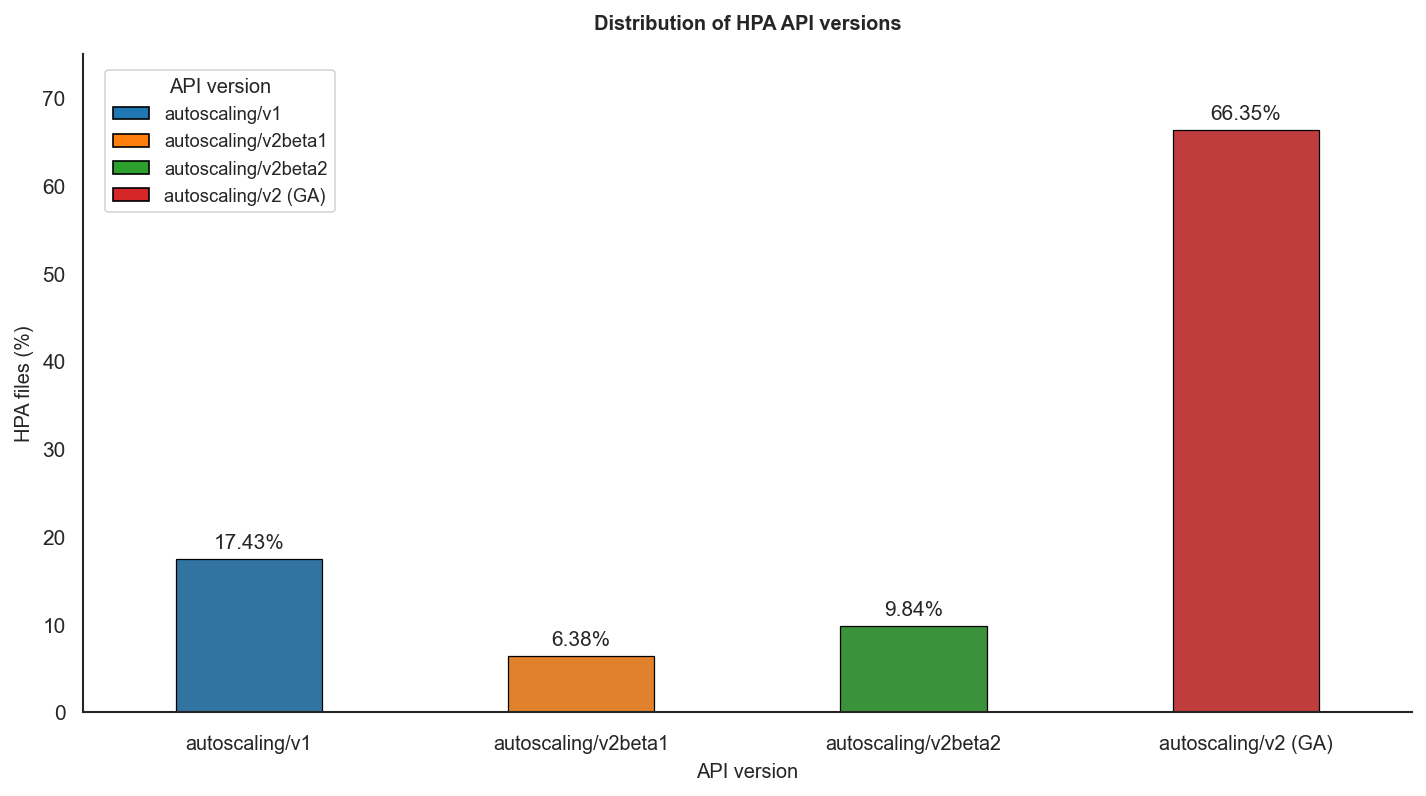


--- Numbers for the paper ---
autoscaling/v1                : 1,702  (17.43%)  | repositories: 1,237
autoscaling/v2beta1           :   623  (6.38%)  | repositories:   455
autoscaling/v2beta2           :   961  (9.84%)  | repositories:   560
autoscaling/v2 (GA)           : 6,478  (66.35%)  | repositories: 4,854


In [9]:
# ── Figure 2: API version distribution ───────────────────────────────────────
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='white', context='paper')

api_n = {a: (_pf['api_g'] == a).sum() for a in API_ORDER}
api_pct = {a: (api_n[a] / N) * 100 for a in API_ORDER}
api_repos = (
    _pf.groupby('api_g')['repo_key']
    .nunique()
    .reindex(API_ORDER)
    .fillna(0)
    .astype(int)
)

labels = [API_LABEL[a] for a in API_ORDER]
values = [api_pct[a] for a in API_ORDER]
api_df_plot = pd.DataFrame({
    'API version': labels,
    'HPA files (%)': values,
})

fig, ax = plt.subplots(figsize=(9.6, 5.4))
sns.barplot(
    data=api_df_plot,
    x='API version',
    y='HPA files (%)',
    hue='API version',
    dodge=False,
    palette=dict(zip(labels, API_COLORS)),
    width=0.44,
    edgecolor='black',
    linewidth=0.6,
    legend=False,
    ax=ax,
)

# extra safety in case seaborn creates more artists than expected
for patch, pct in zip(ax.patches[:len(values)], values):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        pct + max(values) * 0.012,
        f'{pct:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_ylabel('HPA files (%)')
ax.set_xlabel('API version')
ax.set_ylim(0, max(values) * 1.13)
ax.set_title('Distribution of HPA API versions', pad=12)
ax.tick_params(axis='x', labelsize=9.5, pad=6)
ax.tick_params(axis='y', labelsize=10)
sp(ax)
ax.grid(False)

legend_handles = [Patch(facecolor=C[a], edgecolor='black', label=API_LABEL[a]) for a in API_ORDER]
ax.legend(handles=legend_handles, title='API version', loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True)

plt.tight_layout()
savefig('fig02_apiversion_distribution.pdf')
plt.show()

print()
print('--- Numbers for the paper ---')
for a in API_ORDER:
    print(
        f'{API_LABEL[a]:<30}: {api_n[a]:>5,}  '
        f'({api_pct[a]:.2f}%)  | repositories: {api_repos[a]:>5,}'
    )

## 5. Temporal evolution by year of the last HPA-file commit

This section analyzes how the HPA API versions evolve over time, using the year of the last commit touching the HPA file. The granularity is the file, not the whole repository.

The temporal figure shows the persistence of older versions and the expansion of `autoscaling/v2` among the files modified more recently.


In [10]:
# ── Preparacao dos dados para analise temporal (Figura 3) ────────────────────
# Agrupa arquivos por (commit_year, api_g).
# commit_year is available for most files.

by_k = _pf.groupby(['commit_year', 'api_g']).size().unstack(fill_value=0)
by_k = by_k.reindex(columns=API_ORDER, fill_value=0)
anos_k = sorted([int(y) for y in by_k.index if pd.notna(y) and 2015 <= y <= 2026])
by_k   = by_k.loc[[y for y in anos_k if y in by_k.index]]
by_k_pct = by_k.div(by_k.sum(axis=1), axis=0) * 100

# Taxa de spec.behavior por ano — linha de contexto (ver Secao 27 para analise correta)
beh_ano = (
    _pf[_pf['commit_year'].notna()]
    .groupby('commit_year')['has_beh']
    .mean() * 100
).reindex(anos_k, fill_value=np.nan)

print("Arquivos por versao de API e ano do ultimo commit:")
print(by_k.to_string())
print()
print(f"{'Ano':>6} {'N':>6} {'spec.behavior':>15}")
for yr in anos_k:
    n_yr = by_k.loc[yr].sum() if yr in by_k.index else 0
    b_yr = beh_ano.get(yr, float('nan'))
    if n_yr > 0:
        print(f"  {yr}: {n_yr:>5,}   {b_yr:>14.2f}%")


Arquivos por versao de API e ano do ultimo commit:
api_g         v1  v2beta1  v2beta2    v2
commit_year                             
2016           2        0        0     0
2017          35        3        0     0
2018          38       55        0     0
2019         116       77       24     0
2020         134      115       85     0
2021         145      133      179     2
2022         183      100      220    95
2023         241       38      115   343
2024         525       70      209   950
2025         234       31      120  3212
2026          49        1        9  1876

   Ano      N   spec.behavior
  2016:     2             0.00%
  2017:    38             0.00%
  2018:    93             0.00%
  2019:   217             0.46%
  2020:   334             1.50%
  2021:   459             5.01%
  2022:   598             9.20%
  2023:   737             7.19%
  2024: 1,754            10.78%
  2025: 3,597            38.12%
  2026: 1,935            45.32%


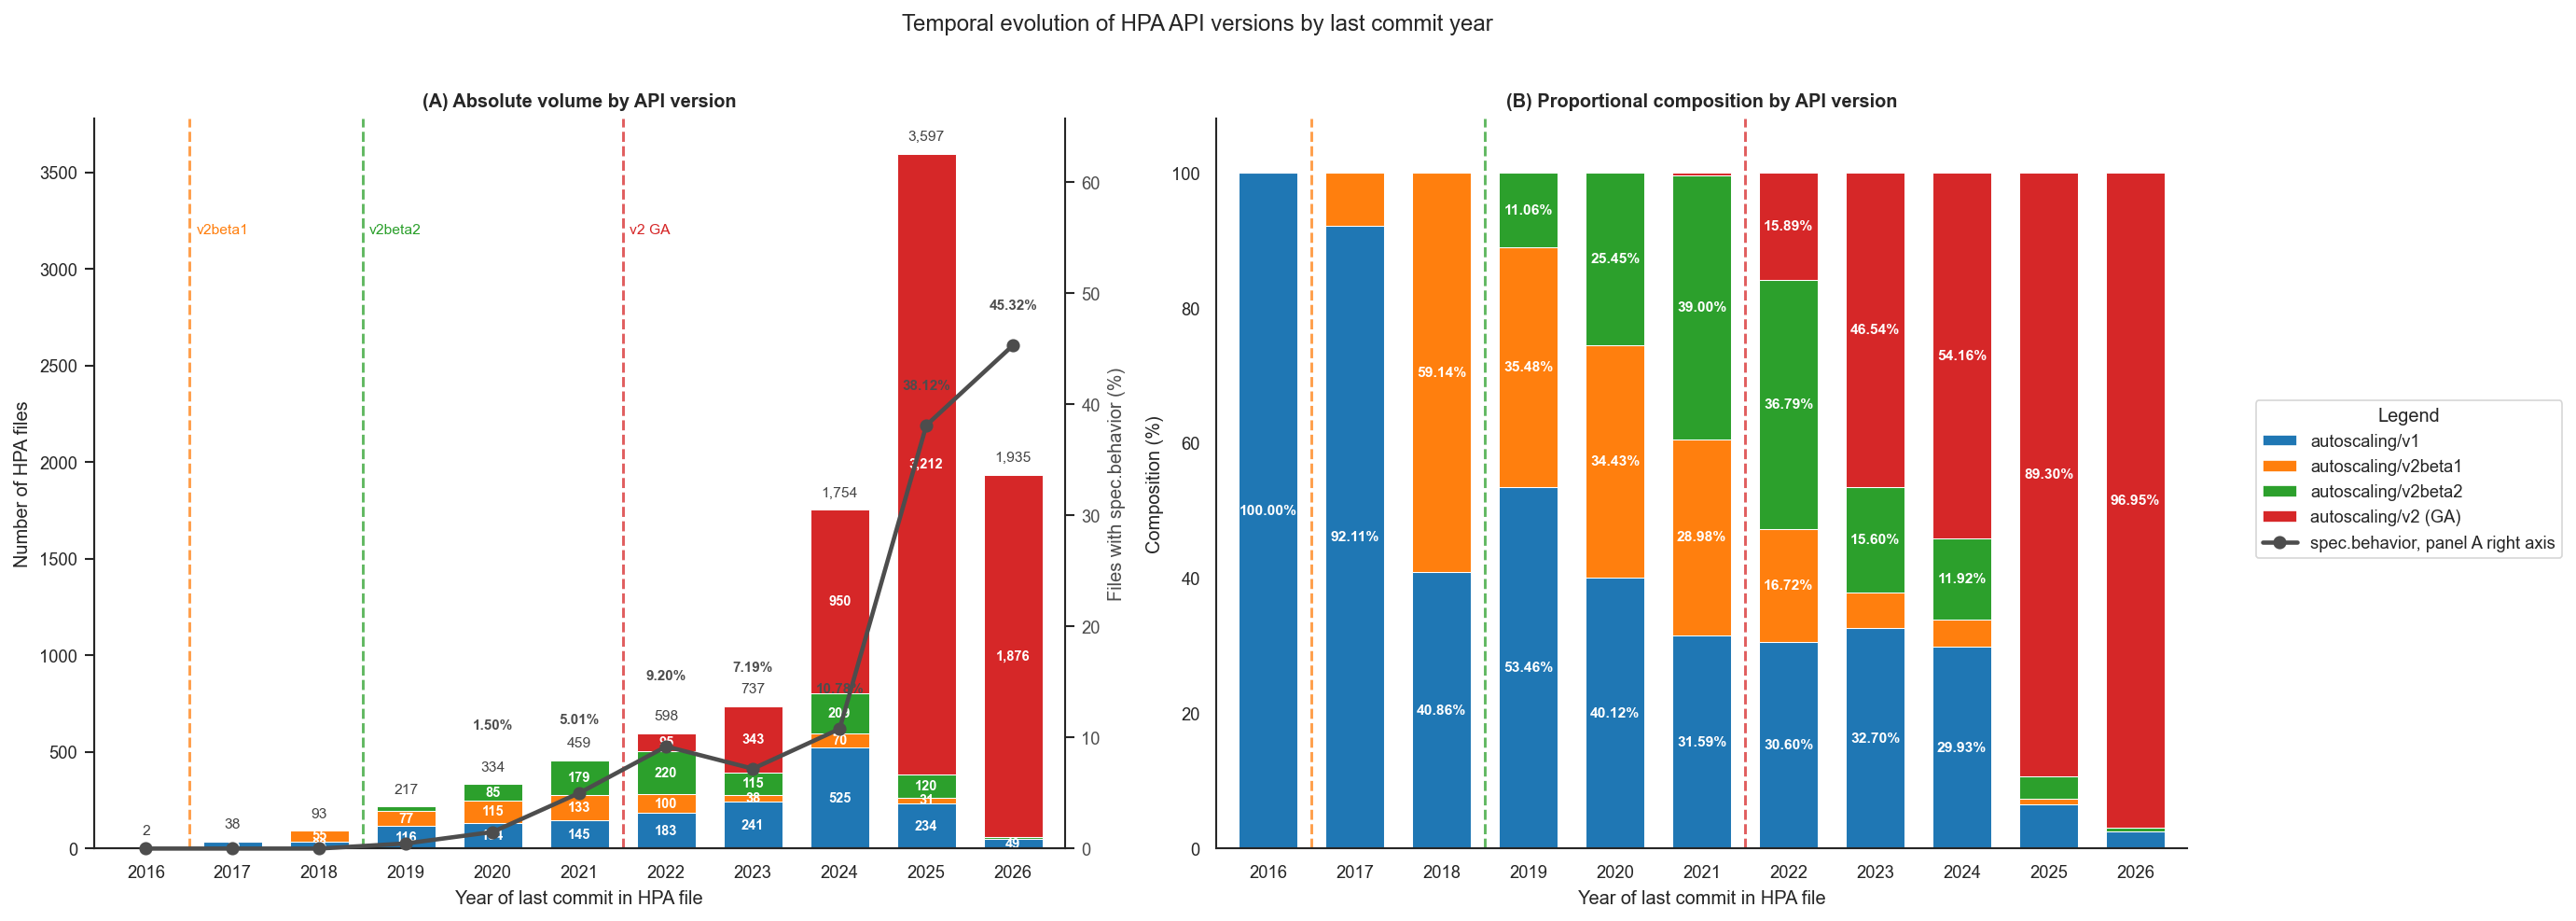

Figure 3 displayed and saved as PDF.


In [11]:
# ── Figure 3: Temporal evolution by last commit year ─────────────────────────
import seaborn as sns

sns.set_theme(style='white', context='paper')

x = np.arange(len(anos_k))
w = 0.68
fig, axes = plt.subplots(1, 2, figsize=(17.2, 6.4))
BEH_LINE_COLOR = '#4D4D4D'

# Panel A: absolute volumes
ax1 = axes[0]
bottoms = np.zeros(len(anos_k))
for api in API_ORDER:
    vals = by_k[api].values if api in by_k.columns else np.zeros(len(anos_k))
    ax1.bar(x, vals, bottom=bottoms, color=C[api], edgecolor='white', lw=0.5, width=w, zorder=2)
    for xi, (v, bot) in enumerate(zip(vals, bottoms)):
        if v >= 30:
            ax1.text(xi, bot + v / 2, f'{v:,.0f}', ha='center', va='center', fontsize=7,
                     color='white', fontweight='bold', zorder=3)
    bottoms += vals

for xi, yr in enumerate(anos_k):
    t = by_k.loc[yr].sum() if yr in by_k.index else 0
    if t > 0:
        ax1.text(xi, t + max(bottoms) * 0.015, f'{t:,}', ha='center', fontsize=7.5,
                 color='#444444', va='bottom')

ax1r = ax1.twinx()
beh_y = [beh_ano.get(yr, np.nan) for yr in anos_k]
ax1r.plot(x, beh_y, color=BEH_LINE_COLOR, lw=2.2, marker='o', ms=5.8,
          zorder=5, clip_on=False, label='Files with spec.behavior')

for xi, (yr, bv) in enumerate(zip(anos_k, beh_y)):
    if not np.isnan(bv) and bv >= 1:
        extra_offsets = {2020: 6.0, 2021: 3.0, 2022: 2.8, 2023: 5.5}
        extra_offset = extra_offsets.get(yr, 0.0)
        ax1r.text(xi, bv + 3.0 + extra_offset, f'{bv:.2f}%', ha='center', va='bottom',
                  fontsize=7.3, color=BEH_LINE_COLOR, fontweight='bold')

ax1r.set_ylabel('Files with spec.behavior (%)', color=BEH_LINE_COLOR)
ax1r.tick_params(axis='y', labelcolor=BEH_LINE_COLOR)
_beh_max = max(v for v in beh_y if not np.isnan(v))
ax1r.set_ylim(0, _beh_max * 1.45)
ax1r.set_xlim(ax1.get_xlim())
ax1r.spines['top'].set_visible(False)

release_lines = [(2017, 'v2beta1', C['v2beta1']), (2019, 'v2beta2', C['v2beta2']), (2022, 'v2 GA', C['v2'])]
for yr_r, lbl_r, col_r in release_lines:
    if yr_r in anos_k:
        xi_r = anos_k.index(yr_r)
        ax1.axvline(xi_r - 0.5, color=col_r, lw=1.4, ls='--', alpha=0.75, zorder=1)
        ax1.text(xi_r - 0.42, max(bottoms) * 0.90, lbl_r, fontsize=7.5, color=col_r, va='top')

ax1.set_xticks(x)
ax1.set_xticklabels(anos_k, rotation=0)
ax1.set_xlabel('Year of last commit in HPA file')
ax1.set_ylabel('Number of HPA files')
ax1.set_title('(A) Absolute volume by API version')
ax1.set_xlim(-0.6, len(anos_k) - 0.4)
sp(ax1)
ax1.grid(False)

# Panel B: proportional composition
ax2 = axes[1]
bottoms_p = np.zeros(len(anos_k))
for api in API_ORDER:
    vals_p = by_k_pct[api].values if api in by_k_pct.columns else np.zeros(len(anos_k))
    ax2.bar(x, vals_p, bottom=bottoms_p, color=C[api], edgecolor='white', lw=0.5,
            width=w, label=API_LABEL[api])
    for xi, (v, bot) in enumerate(zip(vals_p, bottoms_p)):
        if v >= 9:
            ax2.text(xi, bot + v / 2, f'{v:.2f}%', ha='center', va='center', fontsize=7.5,
                     color='white', fontweight='bold')
    bottoms_p += vals_p

for yr_r, _, col_r in release_lines:
    if yr_r in anos_k:
        xi_r = anos_k.index(yr_r)
        ax2.axvline(xi_r - 0.5, color=col_r, lw=1.4, ls='--', alpha=0.75)

ax2.set_xticks(x)
ax2.set_xticklabels(anos_k, rotation=0)
ax2.set_xlabel('Year of last commit in HPA file')
ax2.set_ylabel('Composition (%)')
ax2.set_title('(B) Proportional composition by API version')
ax2.set_ylim(0, 108)
ax2.set_xlim(-0.6, len(anos_k) - 0.4)
sp(ax2)
ax2.grid(False)

handles = [mpa.Patch(facecolor=C[a], label=API_LABEL[a]) for a in API_ORDER]
handles.append(plt.Line2D([0], [0], color=BEH_LINE_COLOR, lw=2.2, marker='o', ms=5.8,
                          label='spec.behavior, panel A right axis'))
fig.legend(handles=handles, title='Legend', loc='center left', bbox_to_anchor=(0.94, 0.5),
           frameon=True, borderaxespad=0.)
fig.suptitle('Temporal evolution of HPA API versions by last commit year', y=1.02)

plt.tight_layout(rect=[0, 0, 0.92, 1])
savefig('fig03_temporal_commit_year.pdf')
plt.show()

print('Figure 3 displayed and saved as PDF.')


### 5.1 Reading the temporal evolution

This section should be read from the `print` output and the figure produced by the previous cell. In particular, look at the composition per version in recent years and at the presence of older files still modified after `autoscaling/v2` became available.


## 6. HPA Feature Richness Score (HFRS)

The HFRS summarizes the structural richness of the HPA configurations. The score considers dimensions such as the API version, the presence of `spec.behavior`, the use of multiple metrics, `minReplicas`, memory metrics, and custom metrics.

In this minimal version the HFRS contextualizes the archetypes and the relationships between capabilities, without reproducing every exploratory analysis of the full version.


### 6.1 Loading the HFRS datasets

This step loads the files derived from the HFRS computation and prepares the tables used in the next sections. When the files are not available, run the previous notebook or check whether the bootstrap extracted `data.zip` correctly.


In [12]:
# ── Carregar HFRS (gerado pelo NB1 Phase 5-B) ─────────────────────────────────
pf_hfrs = pd.read_csv(DATA_DIR / 'hpa_hfrs.csv')

RICHNESS_COLORS = {
    'Minimal':     '#aec7e8',
    'Basic':       '#74c476',
    'Moderate':    '#fd8d3c',
    'Rich':        '#e6550d',
    'Highly Rich': '#756bb1',
}
RICHNESS_ORDER = ['Minimal', 'Basic', 'Moderate', 'Rich', 'Highly Rich']

print(f"hpa_hfrs.csv loaded: {len(pf_hfrs):,} HPA files")
print()
print("Distribuição por classe de riqueza:")
rc_counts = pf_hfrs['richness_class'].value_counts()
for cls in RICHNESS_ORDER:
    n = rc_counts.get(cls, 0)
    print(f"  {cls:<12} {n:>5} ({n/len(pf_hfrs)*100:.2f}%)")
print()
print(f"HFRS: média={pf_hfrs['HFRS'].mean():.2f}, mediana={pf_hfrs['HFRS'].median():.0f}, "
      f"min={pf_hfrs['HFRS'].min():.0f}, max={pf_hfrs['HFRS'].max():.0f}")


hpa_hfrs.csv loaded: 9,764 HPA files

Distribuição por classe de riqueza:
  Minimal        142 (1.45%)
  Basic         5434 (55.65%)
  Moderate      2142 (21.94%)
  Rich          1678 (17.19%)
  Highly Rich    368 (3.77%)

HFRS: média=5.94, mediana=4, min=0, max=13


In [13]:
# ── Constantes HFRS (usadas nas seções seguintes) ─────────────────────────────
# pf_hfrs is loaded in the cell below; Phase 5-B of Notebook 1 writes the CSV.
# Definir aqui as constantes para compatibilidade com visualizações posteriores.
V1_ALIASES       = {'autoscaling/v1', 'v1', 'autoscaling/V1'}
NON_RESOURCE_SET = {'pods', 'object', 'external'}


## 7. HPA configuration archetypes

This section groups HPA configurations into structural archetypes based on the observed capabilities, such as the use of a v2 version, additional metrics, `spec.behavior`, and replica values.

The goal is to describe recurring configuration patterns, and not to classify an individual configuration as correct or incorrect.


HPA configuration archetypes:
  1-Minimal legacy             n= 1668 (17.08%)  mean HFRS=2.96
  2-Basic v2 migration         n= 3592 (36.79%)  mean HFRS=3.88
  3-Dual-resource              n= 1603 (16.42%)  mean HFRS=6.46
  4-Behavior-aware             n= 2121 (21.72%)  mean HFRS=9.97
  5-Signal-rich                n=  780 (7.99%)  mean HFRS=9.77


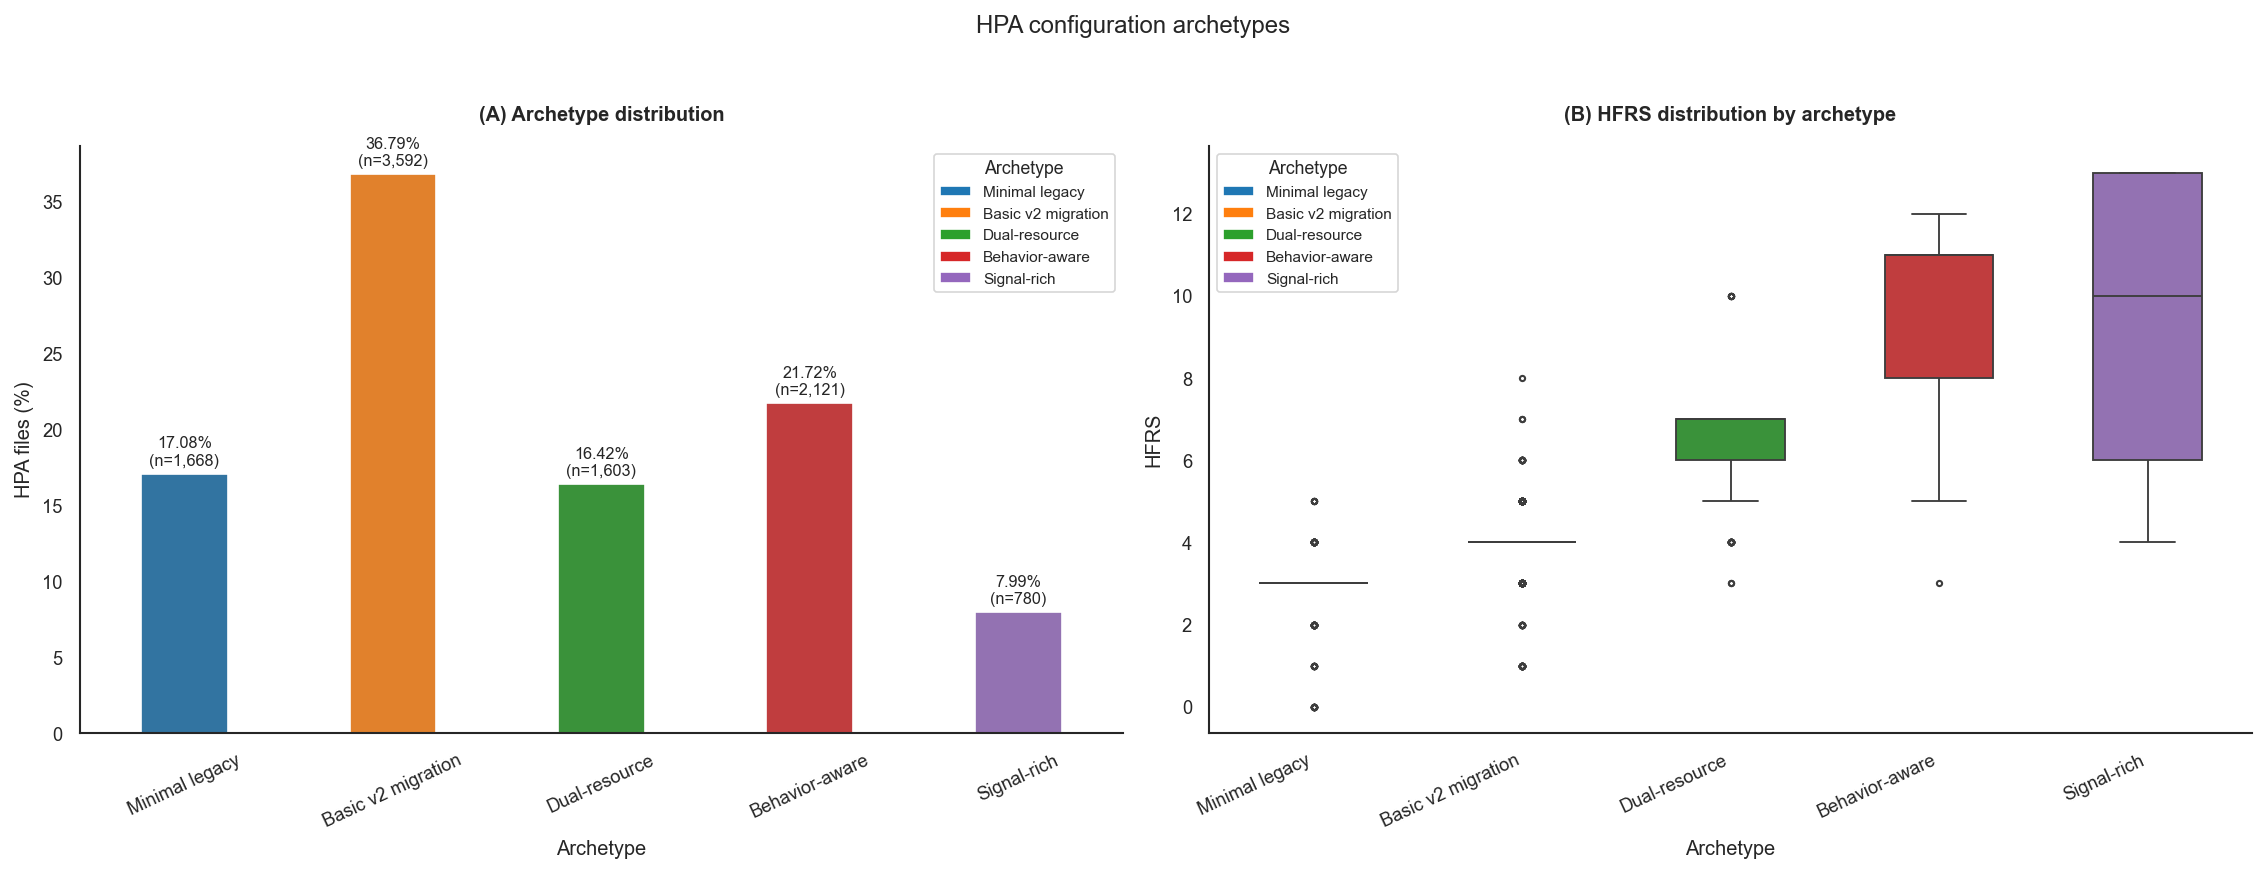

Figure 25B displayed and saved as PDF.


In [14]:
# ── Figure 25B: HPA configuration archetypes ─────────────────────────────────
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

def classify_archetype(row):
    if row['SR1'] == 0 and row['SR3'] == 0 and row['CR1'] == 0:
        return '1-Minimal legacy'
    if row['SR4'] == 1:
        return '5-Signal-rich'
    if row['CR1'] == 1:
        return '4-Behavior-aware'
    if row['SR3'] == 1:
        return '3-Dual-resource'
    return '2-Basic v2 migration'

pf_hfrs['archetype'] = pf_hfrs.apply(classify_archetype, axis=1)

arch_order = [
    '1-Minimal legacy',
    '2-Basic v2 migration',
    '3-Dual-resource',
    '4-Behavior-aware',
    '5-Signal-rich',
]
arch_labels = [a.split('-', 1)[1] for a in arch_order]
arch_palette = {
    '1-Minimal legacy': '#1f77b4',
    '2-Basic v2 migration': '#ff7f0e',
    '3-Dual-resource': '#2ca02c',
    '4-Behavior-aware': '#d62728',
    '5-Signal-rich': '#9467bd',
}

arch_counts = pf_hfrs['archetype'].value_counts()
print('HPA configuration archetypes:')
for a in arch_order:
    n = arch_counts.get(a, 0)
    hfrs_mean = pf_hfrs[pf_hfrs['archetype'] == a]['HFRS'].mean()
    print(f'  {a:<28} n={n:>5} ({n/len(pf_hfrs)*100:.2f}%)  mean HFRS={hfrs_mean:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.6))

# Panel A: archetype distribution
ax = axes[0]
arch_df = pd.DataFrame({
    'Archetype': arch_order,
    'Label': arch_labels,
    'Share (%)': [arch_counts.get(a, 0) / len(pf_hfrs) * 100 for a in arch_order],
    'Count': [arch_counts.get(a, 0) for a in arch_order],
})
sns.barplot(
    data=arch_df,
    x='Label',
    y='Share (%)',
    hue='Archetype',
    order=arch_labels,
    hue_order=arch_order,
    palette=arch_palette,
    dodge=False,
    legend=False,
    errorbar=None,
    ax=ax,
)
for patch in ax.patches:
    w = patch.get_width()
    c = patch.get_x() + w / 2
    new_w = w * 0.52
    patch.set_width(new_w)
    patch.set_x(c - new_w / 2)
for i, row in enumerate(arch_df.itertuples(index=False)):
    ax.text(i, row[2] + 0.35, f'{row[2]:.2f}%\n(n={row[3]:,})', ha='center', va='bottom', fontsize=7.8)
ax.set_xlabel('Archetype')
ax.set_ylabel('HPA files (%)')
ax.set_title('(A) Archetype distribution', pad=12)
ax.tick_params(axis='x', rotation=25)
legend_a = [Patch(facecolor=arch_palette[a], edgecolor='white', label=a.split('-', 1)[1]) for a in arch_order]
ax.legend(handles=legend_a, title='Archetype', frameon=True, loc='upper right', fontsize=7.4, title_fontsize=8.5)
sp(ax)
ax.grid(False)

# Panel B: HFRS distribution by archetype
ax = axes[1]
sns.boxplot(
    data=pf_hfrs,
    x='archetype',
    y='HFRS',
    order=arch_order,
    palette=arch_palette,
    width=0.52,
    linewidth=0.9,
    fliersize=2.5,
    ax=ax,
)
ax.set_xticklabels(arch_labels, rotation=25, ha='right')
ax.set_xlabel('Archetype')
ax.set_ylabel('HFRS')
ax.set_title('(B) HFRS distribution by archetype', pad=12)
legend_b = [Patch(facecolor=arch_palette[a], edgecolor='white', label=a.split('-', 1)[1]) for a in arch_order]
ax.legend(handles=legend_b, title='Archetype', frameon=True, loc='upper left', fontsize=7.4, title_fontsize=8.5)
sp(ax)
ax.grid(False)

fig.suptitle('HPA configuration archetypes', y=1.03)
plt.tight_layout()
savefig('fig25b_hfrs_archetypes.pdf')
plt.show()
print('Figure 25B displayed and saved as PDF.')


## 8. Adoption of specific capabilities over time

This section tracks the adoption of relevant HPA fields and capabilities over the years, such as `spec.behavior`, memory metrics, custom metrics, and configurations with `minReplicas >= 2`.

The analysis separates the adoption of an API version from the actual use of the capabilities that version offers.


In [15]:
# ── Restored analytical prints, capability adoption by year ──────────────────
# This cell rebuilds the capability flags if the restored source columns are absent.
try:
    _tmp = _pf.copy()
    _tmp['repo_key'] = _tmp['Owner'].astype(str) + '/' + _tmp['Project'].astype(str)

    # Add commit year when available from the Phase 3 commit dataset.
    if 'commit_year' not in _tmp.columns:
        try:
            _p3_commit = pd.read_csv(DATA_DIR / 'phase3_file_commits_latest.csv')
            _p3_commit['commit_year'] = pd.to_datetime(_p3_commit['file_last_commit'], errors='coerce', utc=True).dt.year
            _tmp = _tmp.merge(
                _p3_commit[['Owner', 'Project', 'File Path', 'commit_year']],
                on=['Owner', 'Project', 'File Path'],
                how='left'
            )
        except Exception:
            _tmp['commit_year'] = np.nan

    _tmp['has_memory'] = _tmp['nomes_set'].apply(lambda x: 'memory' in x)
    _tmp['has_custom_metrics'] = _tmp['tipos_set'].apply(
        lambda x: bool(x & {'pods', 'external', 'object', 'containerresource'})
    )
    _tmp['is_multi_metric'] = pd.to_numeric(_tmp['n_tipos'], errors='coerce').fillna(0).ge(2)
    _tmp['min_ge_2'] = pd.to_numeric(_tmp['min_r'], errors='coerce').ge(2)

    candidates = {
        'behavior': 'has_beh',
        'memory': 'has_memory',
        'custom_metrics': 'has_custom_metrics',
        'multi_metric': 'is_multi_metric',
        'minReplicas>=2': 'min_ge_2',
    }
    rows = {
        name: _tmp.groupby('commit_year')[col].mean() * 100
        for name, col in candidates.items()
        if col in _tmp.columns and 'commit_year' in _tmp.columns
    }
    print('\nCapability adoption by year (%):')
    if rows:
        print(pd.DataFrame(rows).round(1).dropna(how='all').to_string())
    else:
        print('  No rows could be computed from the available columns.')
except Exception as e:
    print(f'Capability adoption table could not be computed in this environment: {e}')



Capability adoption by year (%):
             behavior  memory  custom_metrics  multi_metric  minReplicas>=2
commit_year                                                                
2016              0.0     0.0             0.0           0.0            50.0
2017              0.0     2.6             5.3           0.0            42.1
2018              0.0    15.1            10.8           3.2            30.1
2019              0.5     7.4            11.1           0.9            28.1
2020              1.5     8.4             9.9           2.1            33.5
2021              5.0    11.1            10.5           3.3            26.1
2022              9.2    14.4             7.9           0.8            25.3
2023              7.2    13.7             7.2           1.8            29.3
2024             10.8    18.9             5.2           1.1            39.0
2025             38.1    50.8            13.7           7.8            56.6
2026             45.3    55.0             9.1         

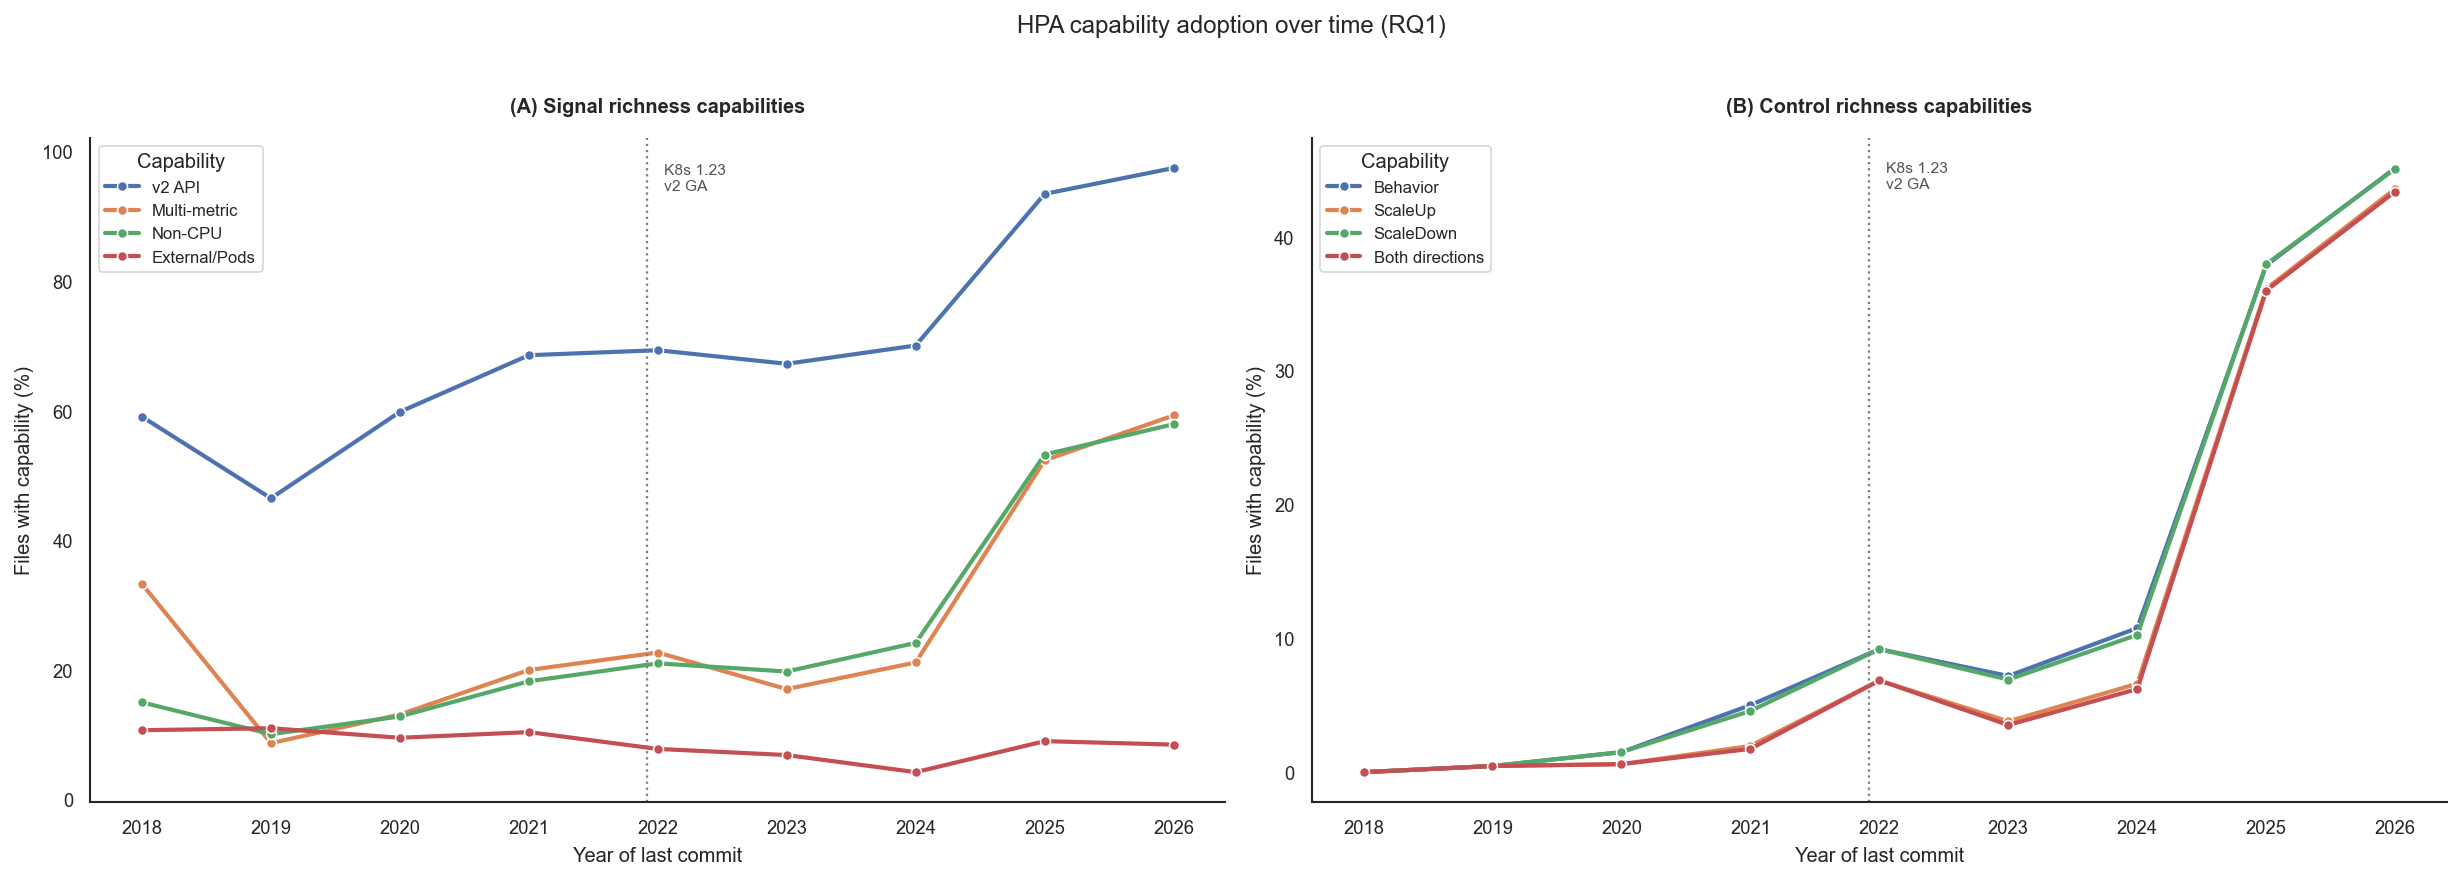

In [16]:
# ── Figure 30: capability adoption over time ─────────────────────────────────
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')
hf = pd.read_csv(DATA_DIR / 'hpa_hfrs_full.csv')
hf['commit_year'] = pd.to_numeric(hf['commit_year'], errors='coerce')
hf_yr = hf[hf['commit_year'].between(2018, 2026)]
years = list(range(2018, 2027))

CAPABILITIES = {
    'v2 API': 'SR1',
    'Multi-metric': 'SR2',
    'Non-CPU': 'SR3',
    'External/Pods': 'SR4',
    'Behavior': 'CR1',
    'ScaleUp': 'CR2',
    'ScaleDown': 'CR3',
    'Both directions': 'CR4',
}
rows = []
for label, col in CAPABILITIES.items():
    group = 'Signal richness' if col.startswith('SR') else 'Control richness'
    for y in years:
        sub = hf_yr[hf_yr['commit_year'] == y]
        rows.append({'Year': y, 'Capability': label, 'Group': group,
                     'Adoption (%)': sub[col].mean() * 100 if len(sub) else np.nan})
adop_long = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.7))
for ax, group in zip(axes, ['Signal richness', 'Control richness']):
    sub = adop_long[adop_long['Group'] == group]
    sns.lineplot(data=sub, x='Year', y='Adoption (%)', hue='Capability',
                 marker='o', linewidth=2, ax=ax)
    ax.axvline(2021.92, color='#7f7f7f', linestyle=':', linewidth=1.1)
    ax.text(2022.05, ax.get_ylim()[1]*0.92, 'K8s 1.23\nv2 GA', fontsize=7.5, color='#555555')
    ax.set_xlabel('Year of last commit')
    ax.set_ylabel('Files with capability (%)')
    ax.set_title(f'({ "A" if group.startswith("Signal") else "B" }) {group} capabilities', pad=12)
    ax.legend(title='Capability', frameon=True, loc='upper left', fontsize=8)
    sp(ax); ax.grid(False)
fig.suptitle('HPA capability adoption over time (RQ1)', y=1.02)
plt.tight_layout()
savefig('fig30_capability_adoption_over_time.pdf')
plt.show()


## 9. Adoption lag between Kubernetes releases and use in the corpus

This section measures the interval between the availability of an HPA API version in Kubernetes and its appearance in the files of the corpus. It shows the adoption delay, the persistence of beta versions, and the persistence of `autoscaling/v1`.

The next cell prints the lag statistics per version and produces the corresponding figure.


In [17]:
# ── Restored analytical prints from original notebook, original cell 84 ──
# Source section: from pathlib import Path

try:
    _hf_lag = hf.copy()
    if 'api_norm' not in _hf_lag.columns:
        _hf_lag['api_norm'] = _hf_lag.get('api_g', _hf_lag.get('apiVersion')).astype(str).str.replace('autoscaling/', '', regex=False)
    if 'file_last_commit' in _hf_lag.columns:
        _hf_lag['file_last_commit'] = pd.to_datetime(_hf_lag['file_last_commit'], errors='coerce', utc=True)
        RELEASES = {
            'v1': pd.Timestamp('2016-03-16', tz='UTC'),
            'v2beta1': pd.Timestamp('2017-03-29', tz='UTC'),
            'v2beta2': pd.Timestamp('2018-09-27', tz='UTC'),
            'v2': pd.Timestamp('2021-12-07', tz='UTC'),
        }
        for api, release in RELEASES.items():
            sub = _hf_lag[(_hf_lag['api_norm'] == api) & _hf_lag['file_last_commit'].notna()].copy()
            sub['lag_days'] = (sub['file_last_commit'] - release).dt.days
            sub = sub[sub['lag_days'] >= 0]
            if len(sub):
                print(f"{api}: n={len(sub)}, median={sub['lag_days'].median():.0f}d ({sub['lag_days'].median()/365:.1f}y), ≤1yr={(sub['lag_days']<=365).mean()*100:.2f}%")
    else:
        print('API migration lag summary unavailable: file_last_commit not found.')
except Exception as e:
    print(f'API migration lag summary unavailable: {e}')


v1: n=1689, median=2800d (7.7y), ≤1yr=0.18%
v2beta1: n=623, median=1501d (4.1y), ≤1yr=0.96%
v2beta2: n=961, median=1478d (4.0y), ≤1yr=1.35%
v2: n=6475, median=1386d (3.8y), ≤1yr=1.27%


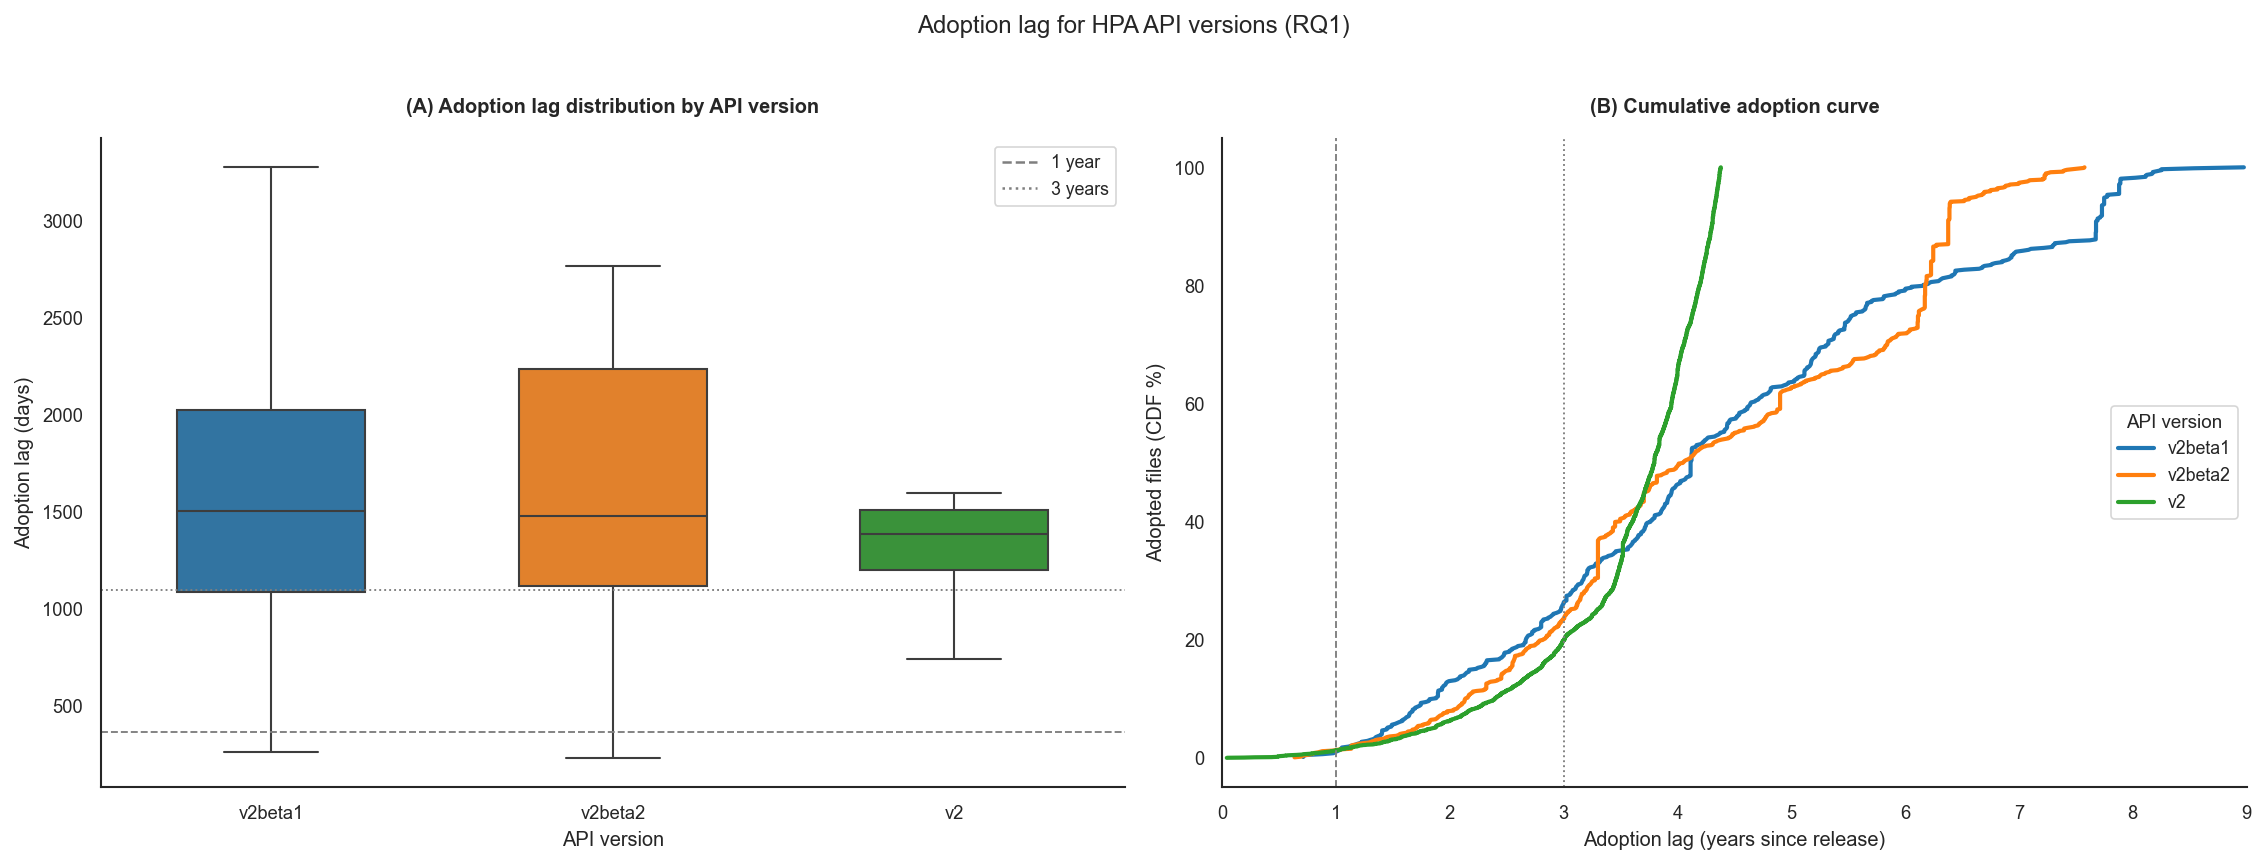

In [18]:
# ── Figure 31: API adoption lag ─────────────────────────────────────────────
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style='white', context='paper')
hf = pd.read_csv(DATA_DIR / 'hpa_hfrs_full.csv')
hf['file_last_commit'] = pd.to_datetime(hf['file_last_commit'], utc=True, errors='coerce')
RELEASES = {
    'autoscaling/v2beta1': pd.Timestamp('2017-03-28', tz='UTC'),
    'autoscaling/v2beta2': pd.Timestamp('2018-09-27', tz='UTC'),
    'autoscaling/v2': pd.Timestamp('2021-12-07', tz='UTC'),
}
def norm_api(v):
    v = str(v).strip()
    if v in {'autoscaling/v1','v1','autoscaling/V1'}: return 'autoscaling/v1'
    if 'v2beta1' in v: return 'autoscaling/v2beta1'
    if 'v2beta2' in v: return 'autoscaling/v2beta2'
    if v.startswith('autoscaling/v2'): return 'autoscaling/v2'
    return None
hf['api_norm'] = hf['apiVersion'].apply(norm_api)

lag_rows = []
for api, release in RELEASES.items():
    sub = hf[(hf['api_norm'] == api) & hf['file_last_commit'].notna()].copy()
    sub['Lag days'] = (sub['file_last_commit'] - release).dt.days
    sub = sub[sub['Lag days'] >= 0]
    for v in sub['Lag days'].dropna():
        lag_rows.append({'API version': api.replace('autoscaling/', ''), 'Lag days': v, 'Lag years': v / 365.0})
lag_df = pd.DataFrame(lag_rows)
api_order = ['v2beta1', 'v2beta2', 'v2']
api_palette = {'v2beta1': '#1f77b4', 'v2beta2': '#ff7f0e', 'v2': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.6))
ax = axes[0]
sns.boxplot(data=lag_df, x='API version', y='Lag days', order=api_order,
            palette=api_palette, showfliers=False, width=0.55, ax=ax)
ax.axhline(365, color='#7f7f7f', linestyle='--', linewidth=0.9)
ax.axhline(1095, color='#7f7f7f', linestyle=':', linewidth=0.9)
ax.set_xlabel('API version')
ax.set_ylabel('Adoption lag (days)')
ax.set_title('(A) Adoption lag distribution by API version', pad=12)
ax.legend(handles=[
    Line2D([0],[0], color='#7f7f7f', linestyle='--', label='1 year'),
    Line2D([0],[0], color='#7f7f7f', linestyle=':', label='3 years'),
], frameon=True, loc='upper right', fontsize=8.5)
sp(ax); ax.grid(False)

ax = axes[1]
for api in api_order:
    sub = np.sort(lag_df[lag_df['API version'] == api]['Lag years'].values)
    if len(sub):
        ax.plot(sub, np.arange(1, len(sub)+1) / len(sub) * 100,
                color=api_palette[api], linewidth=2, label=api)
ax.axvline(1, color='#7f7f7f', linestyle='--', linewidth=0.9)
ax.axvline(3, color='#7f7f7f', linestyle=':', linewidth=0.9)
ax.set_xlabel('Adoption lag (years since release)')
ax.set_ylabel('Adopted files (CDF %)')
ax.set_title('(B) Cumulative adoption curve', pad=12)
ax.set_xlim(0, 9)
ax.legend(title='API version', frameon=True, loc='center right', fontsize=8.5, title_fontsize=9.0)
sp(ax); ax.grid(False)

fig.suptitle('Adoption lag for HPA API versions (RQ1)', y=1.02)
plt.tight_layout()
savefig('fig31_api_migration_lag.pdf')
plt.show()


## 10. Cohort analysis by repository creation year

The cohort analysis groups repositories by creation year and observes the composition of HPA versions in each group. It compares repositories created before and after `autoscaling/v2` stabilized.

The figure reports the shares per cohort.


In [19]:
# ── Restored analytical prints, repository cohort distribution ───────────────
# Rebuilds the table locally instead of relying on a previous pivot_pct variable.
try:
    _hf_cohort_src = pd.read_csv(DATA_DIR / 'hpa_hfrs_full.csv')
    _agg_cohort_src = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
    _agg_cohort_src['created_at'] = pd.to_datetime(_agg_cohort_src['created_at'], utc=True, errors='coerce')
    _agg_cohort_src['cohort_year'] = _agg_cohort_src['created_at'].dt.year
    _hf_cohort_src['repo_full_name'] = _hf_cohort_src['Owner'] + '/' + _hf_cohort_src['Project']
    _hf_cohort_src = _hf_cohort_src.merge(
        _agg_cohort_src[['repo_full_name', 'cohort_year']],
        on='repo_full_name',
        how='left'
    )

    def _norm_api_for_cohort(v):
        v = str(v).strip()
        if v in {'autoscaling/v1', 'v1', 'autoscaling/V1'}:
            return 'v1'
        if 'v2beta1' in v:
            return 'v2beta1'
        if 'v2beta2' in v:
            return 'v2beta2'
        if v.startswith('autoscaling/v2'):
            return 'v2 GA'
        return None

    _api_order_cohort = ['v1', 'v2beta1', 'v2beta2', 'v2 GA']
    _cohort_years = list(range(2016, 2026))
    _hf_cohort_src['API version'] = _hf_cohort_src['apiVersion'].apply(_norm_api_for_cohort)
    _hf_cohort_filtered = _hf_cohort_src[_hf_cohort_src['cohort_year'].between(2016, 2025)].dropna(subset=['API version'])
    _pivot_cohort = (
        _hf_cohort_filtered.groupby(['cohort_year', 'API version']).size()
        .unstack(fill_value=0)
        .reindex(index=_cohort_years, columns=_api_order_cohort, fill_value=0)
    )
    _pivot_pct_cohort = _pivot_cohort.div(_pivot_cohort.sum(axis=1), axis=0) * 100
    print('\nDistribution table by repository cohort (%):')
    print(_pivot_pct_cohort.round(1).to_string())
except Exception as e:
    print(f'Repository cohort distribution table unavailable: {e}')



Distribution table by repository cohort (%):
API version    v1  v2beta1  v2beta2  v2 GA
cohort_year                               
2016         58.3      4.2      2.1   35.4
2017         64.4     13.6      5.1   16.9
2018         45.2     34.5      7.7   12.5
2019         44.3     32.9     14.1    8.6
2020         33.0     36.2     24.0    6.8
2021         23.1     23.1     40.0   13.9
2022         32.2     14.9     27.5   25.4
2023         31.5      4.6     14.8   49.2
2024         28.4      4.6     14.6   52.4
2025          5.1      0.3      1.5   93.2


## 11. CPU thresholds below 10%

This section examines `cpu.averageUtilization` configurations below 10%. Very low values may make the HPA scale aggressively, since any real load tends to exceed the configured target quickly.

The analysis quantifies these cases and prints examples for qualitative inspection.


### 11.1 Utility for inspecting the YAML files (`repos_history/`)

This cell defines `read_hpa_yaml(owner, project, file_path)`, used by the qualitative checks of the smell sections. It must run before the cells that inspect examples directly in the YAML files extracted under `data/repos_history/`.


In [20]:
# ── Utilitario de inspecao de YAMLs (repos_history) ─────────────────────────
# Cobertura: 70.7% dos arquivos HPA unicos do phase4 (versao reduzida incluida)
import re as _re
from pathlib import Path as _Path

_REPOS_DIR_UTIL = _Path(globals().get('REPOS_HIST_DIR', DATA_DIR / 'repos_history')).resolve()

# Use _repos_idx from the bootstrap when available, otherwise build it here
if '_repos_idx' not in dir() or not _repos_idx:
    _repos_idx = {}
    if _REPOS_DIR_UTIL.exists():
        for _od in _REPOS_DIR_UTIL.iterdir():
            if not _od.is_dir(): continue
            for _pd2 in _od.iterdir():
                if not _pd2.is_dir(): continue
                _repos_idx[(_od.name, _pd2.name)] = sorted(
                    [_d for _d in _pd2.iterdir() if _d.is_dir()], reverse=True)

def read_hpa_yaml(owner, project, file_path):
    """Return the YAML content of the HPA file taken from repos_history.

    It uses the most recent snapshot, and returns None when none is available.
    """
    key = (owner, project)
    if key not in _repos_idx: return None
    for ts in _repos_idx[key]:
        c = ts / file_path
        if c.exists(): return c.read_text(errors='replace')
    return None

_rh_keys = len(_repos_idx)
print(f"Repositorios indexados em repos_history: {_rh_keys:,}")

# Calcular cobertura real em relacao ao phase4
_cov_total = p4.drop_duplicates(subset=['Owner','Project','File Path']).shape[0]
_cov_real = 0
for _,_r in p4.drop_duplicates(subset=['Owner','Project','File Path']).iterrows():
    _k = (_r['Owner'],_r['Project'])
    if _k in _repos_idx and any((_ts/_r['File Path']).exists() for _ts in _repos_idx[_k]):
        _cov_real += 1
print(f"Cobertura em phase4:   {_cov_real:,} / {_cov_total:,} ({_cov_real/_cov_total*100:.2f}%)")
print(f"Arquivos sem YAML local: {_cov_total-_cov_real:,} ({(1-_cov_real/_cov_total)*100:.2f}%)")
print("Uso: read_hpa_yaml(owner, project, file_path) -> str ou None")
print("NOTA: repos_history incluido e versao reduzida para distribuicao.")
print("      Para 100% de cobertura, execute a Secao 0.2 com GITHUB_TOKEN.")


Repositorios indexados em repos_history: 7,013
Cobertura em phase4:   7,013 / 9,764 (71.83%)
Arquivos sem YAML local: 2,751 (28.17%)
Uso: read_hpa_yaml(owner, project, file_path) -> str ou None
NOTA: repos_history incluido e versao reduzida para distribuicao.
      Para 100% de cobertura, execute a Secao 0.2 com GITHUB_TOKEN.


Valid cpu.averageUtilization entries (>=1): 9,955
  < 10%: 143  (1.44%)
  = 1%:  36  (0.36%)

Distribution of values from 1% to 9%:
    1%:   36  ||||||||||||||||||||||||||||||
    2%:   22  ||||||||||||||||||||||
    3%:    3  |||
    4%:    3  |||
    5%:   76  ||||||||||||||||||||||||||||||
    6%:    1  |
    8%:    1  |
    9%:    1  |

Unique projects with cpu=1%: 35

Sample:
              Owner                     Project                                                          File Path          apiVersion  MaxReplicas  MinReplicas
         linxuyalun                      devops                                      k8s-practice/argus/jd-hpa.yml autoscaling/v2beta2         10.0          1.0
     samirelhassann               fast-food-api                                      deploy/local/api/hpa-api.yaml      autoscaling/v2          3.0          1.0
             leoluz                  kube-tests                                              argocd/nginx/hpa.yaml      autoscaling/

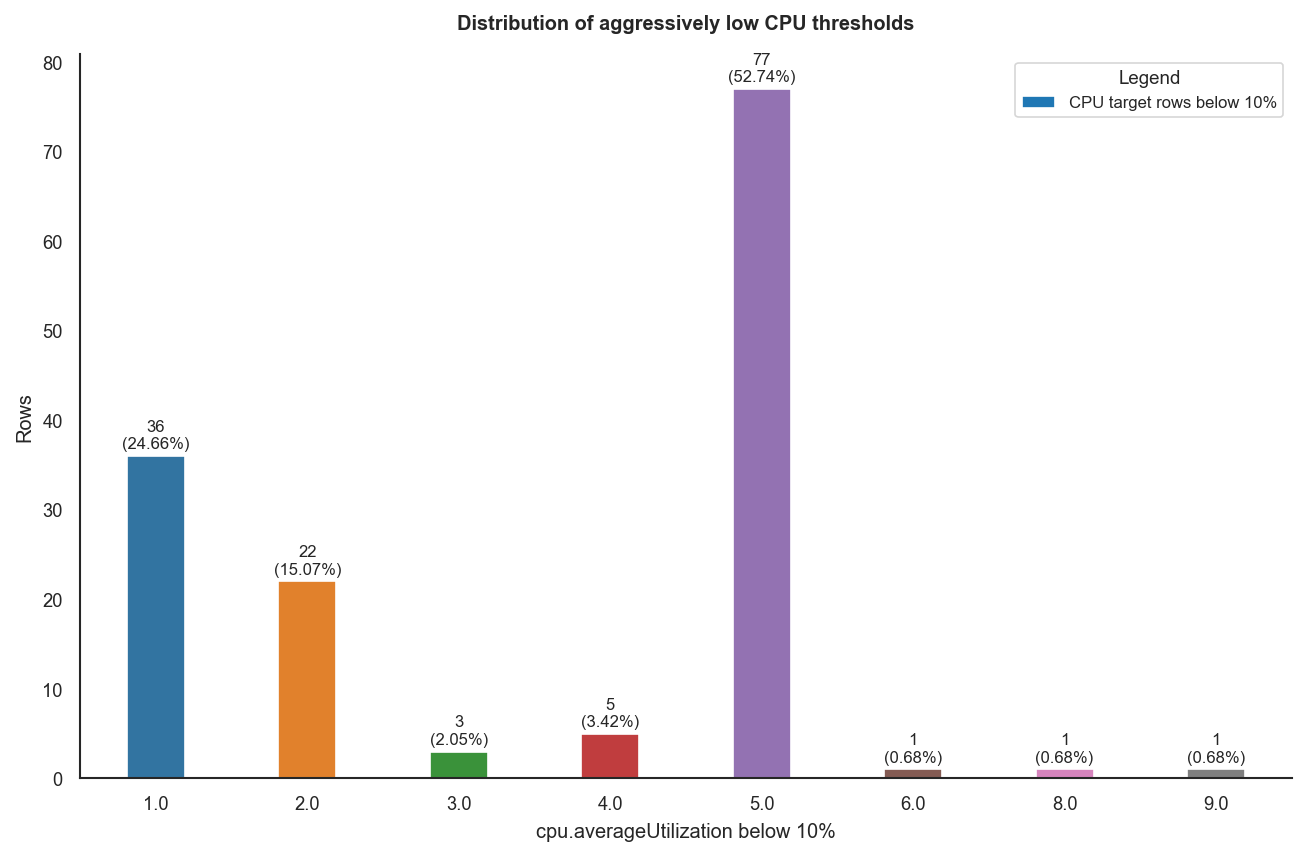

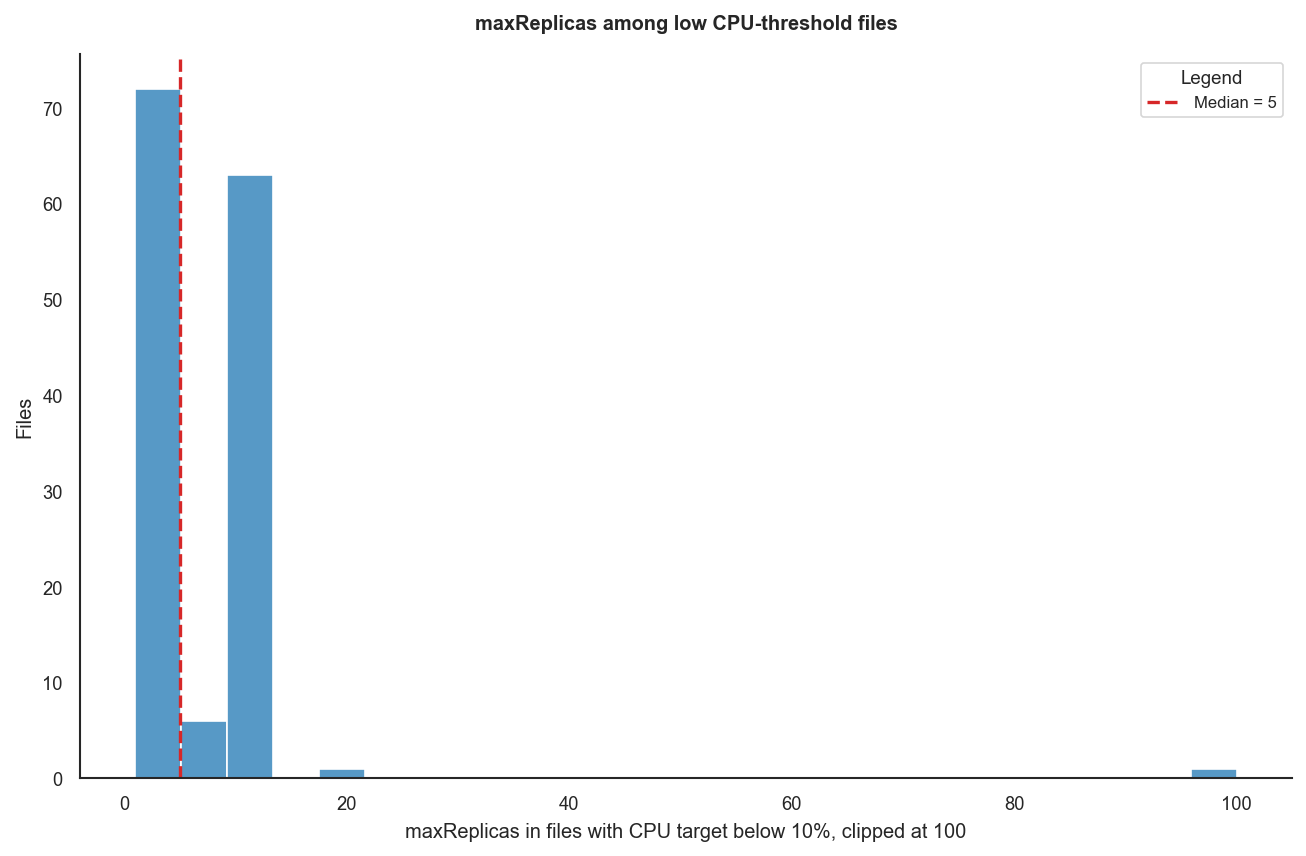

In [21]:
# ── Restored analytical prints from the original notebook ──
# ── Section 44-G: CPU averageUtilization < 10% ───────────────────────────────
# Identifies and characterizes very low CPU thresholds (< 10%)

_cpu_tv = p4[
    (p4['mn_low'] == 'cpu') &
    (p4['tk'].isin(['Utilization', ''])) &
    (p4['Target Value'].notna())
].copy()

_cpu_all  = _cpu_tv[_cpu_tv['Target Value'] >= 1]
_cpu_low  = _cpu_tv[(_cpu_tv['Target Value'] > 0) & (_cpu_tv['Target Value'] < 10)]
_cpu_1pct = _cpu_tv[_cpu_tv['Target Value'] == 1.0]

print(f"Valid cpu.averageUtilization entries (>=1): {len(_cpu_all):,}")
print(f"  < 10%: {len(_cpu_low):,}  ({len(_cpu_low)/len(_cpu_all)*100:.2f}%)")
print(f"  = 1%:  {len(_cpu_1pct):,}  ({len(_cpu_1pct)/len(_cpu_all)*100:.2f}%)")
print()

print("Distribution of values from 1% to 9%:")
for v, cnt in _cpu_low['Target Value'].value_counts().sort_index().items():
    bar = '|' * min(cnt, 30)
    print(f"  {int(v):>3}%: {cnt:>4,}  {bar}")

_cpu1_files = p4[
    (p4['mn_low'] == 'cpu') &
    (p4['Target Value'] == 1.0) &
    (p4['tk'].isin(['Utilization', '']))
][['Owner', 'Project', 'File Path', 'apiVersion', 'MaxReplicas', 'MinReplicas']].drop_duplicates()

print(f"\nUnique projects with cpu=1%: {_cpu1_files[['Owner','Project']].drop_duplicates().shape[0]:,}")
print("\nSample:")
print(_cpu1_files.head(12).to_string(index=False))

_low_merged = _cpu_low.merge(
    _pf[['Owner', 'Project', 'File Path', 'max_r', 'api_g', 'has_beh']],
    on=['Owner', 'Project', 'File Path'],
    how='left'
)

print("\nmaxReplicas in files with cpu<10%:")
print(f"  median: {_low_merged['max_r'].median()}")
print(f"  max:    {_low_merged['max_r'].max()}")

_low_merged_pf = _low_merged.groupby(['Owner', 'Project', 'File Path']).first()
print(f"\nUnique files with cpu<10%: {len(_low_merged_pf)}")

print("\n--- YAML verification: files with cpu=1% ---")
_cpu1_pf = _cpu1_files.drop_duplicates(subset=['Owner', 'Project', 'File Path'])
_verified_g = 0
_inspected_g = 0

for _, row in _cpu1_pf.head(10).iterrows():
    yaml_content = read_hpa_yaml(row['Owner'], row['Project'], row['File Path'])
    if yaml_content:
        _inspected_g += 1
        comment_lines = [
            l.strip() for l in yaml_content.split('\n')
            if l.strip().startswith('#') and len(l.strip()) > 2
        ]
        has_test_keyword = any(
            kw in yaml_content.lower()
            for kw in ['test', 'demo', 'example', 'tutorial', 'benchmark', 'stress', 'load']
        )
        print(f"  {row['Owner']}/{row['Project']}")
        print(f"    test/demo keywords: {has_test_keyword}")
        if comment_lines:
            print(f"    comments: {comment_lines[:2]}")
        _verified_g += 1
    else:
        print(f"  {row['Owner']}/{row['Project']} => YAML not available")
# ── End of restored analytical prints ──

# ── Figure 44G: CPU thresholds below 10% ─────────────────────────────────────
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

cpu_util = p4[(p4['mn_low'] == 'cpu') & (pd.to_numeric(p4['Target Value'], errors='coerce').between(1,100))].copy()
cpu_util['Target Value'] = pd.to_numeric(cpu_util['Target Value'], errors='coerce')
cpu_low = cpu_util[cpu_util['Target Value'] < 10].copy()
low_vc = cpu_low['Target Value'].value_counts().sort_index().reset_index()
low_vc.columns = ['CPU target (%)', 'Rows']
low_vc['Share within low (%)'] = low_vc['Rows'] / len(cpu_low) * 100 if len(cpu_low) else 0
low_files = cpu_low[['Owner','Project','File Path']].drop_duplicates().merge(_pf[['Owner','Project','File Path','max_r','api_g','has_beh']], on=['Owner','Project','File Path'], how='left')

# Figure 44GA
fig, ax = plt.subplots(figsize=(8.8, 5.8))
sns.barplot(data=low_vc, x='CPU target (%)', y='Rows', hue='CPU target (%)', palette='tab10', dodge=False, legend=False, errorbar=None, ax=ax)
for patch in ax.patches:
    w=patch.get_width(); c=patch.get_x()+w/2; new_w=w*0.48
    patch.set_width(new_w); patch.set_x(c-new_w/2)
for i,row in enumerate(low_vc.itertuples(index=False)):
    ax.text(i, row.Rows+0.5, f'{row.Rows:,}\n({row._2:.2f}%)', ha='center', va='bottom', fontsize=8.0)
ax.set_xlabel('cpu.averageUtilization below 10%')
ax.set_ylabel('Rows')
ax.set_title('Distribution of aggressively low CPU thresholds', pad=12)
ax.legend(handles=[Patch(facecolor='#1f77b4', edgecolor='white', label='CPU target rows below 10%')], title='Legend', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig44g_a_cpu_low_threshold_distribution.pdf')
plt.show()

# Figure 44GB
fig, ax = plt.subplots(figsize=(8.8, 5.8))
plot_df = low_files[['max_r']].dropna().copy()
plot_df['maxReplicas'] = plot_df['max_r'].clip(upper=100)
sns.histplot(data=plot_df, x='maxReplicas', bins=24, color='#1f77b4', edgecolor='white', ax=ax)
ax.axvline(plot_df['maxReplicas'].median(), color='#d62728', linestyle='--', linewidth=1.6, label=f'Median = {plot_df["maxReplicas"].median():.0f}')
ax.set_xlabel('maxReplicas in files with CPU target below 10%, clipped at 100')
ax.set_ylabel('Files')
ax.set_title('maxReplicas among low CPU-threshold files', pad=12)
ax.legend(title='Legend', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig44g_b_cpu_low_threshold_maxreplicas.pdf')
plt.show()


## 12. `minReplicas = maxReplicas`: an HPA with no scaling margin

When `spec.minReplicas` equals `spec.maxReplicas`, the HPA has no margin to change the replica count. The controller may still compute a recommendation, but the result is clamped to the single allowed value.

This section separates the `min=max=1` cases from the `min=max` cases with other values, and quantifies the presence of `spec.behavior` in those configurations.


Total with min=max: 369 (3.78%)
  min=max=1 (section 37): 298
  min=max≠1 (this section): 71

Value distribution (min=max≠1):
  2: 47 (66.20% within min=max≠1; 0.48% of corpus)
  3: 15 (21.13% within min=max≠1; 0.15% of corpus)
  4: 5 (7.04% within min=max≠1; 0.05% of corpus)
  5: 2 (2.82% within min=max≠1; 0.02% of corpus)
  14: 1 (1.41% within min=max≠1; 0.01% of corpus)
  20: 1 (1.41% within min=max≠1; 0.01% of corpus)

With spec.behavior configured (min=max, any value):
  Total: 26 (7.05% within min=max)
  Of these, min=max≠1: 6 (8.45% within min=max≠1)

min=max≠1: complete list:
                Owner                         Project   api_g  min_r  max_r  has_beh scale_target
    ArthurVardevanyan                         HomeLab      v2    2.0    2.0    False   Deployment
         Chase-Marino                 retain-hpa-test      v2    2.0    2.0     True   Deployment
           Coronasafe                      automation      v1    4.0    4.0    False   Deployment
           EomYoo

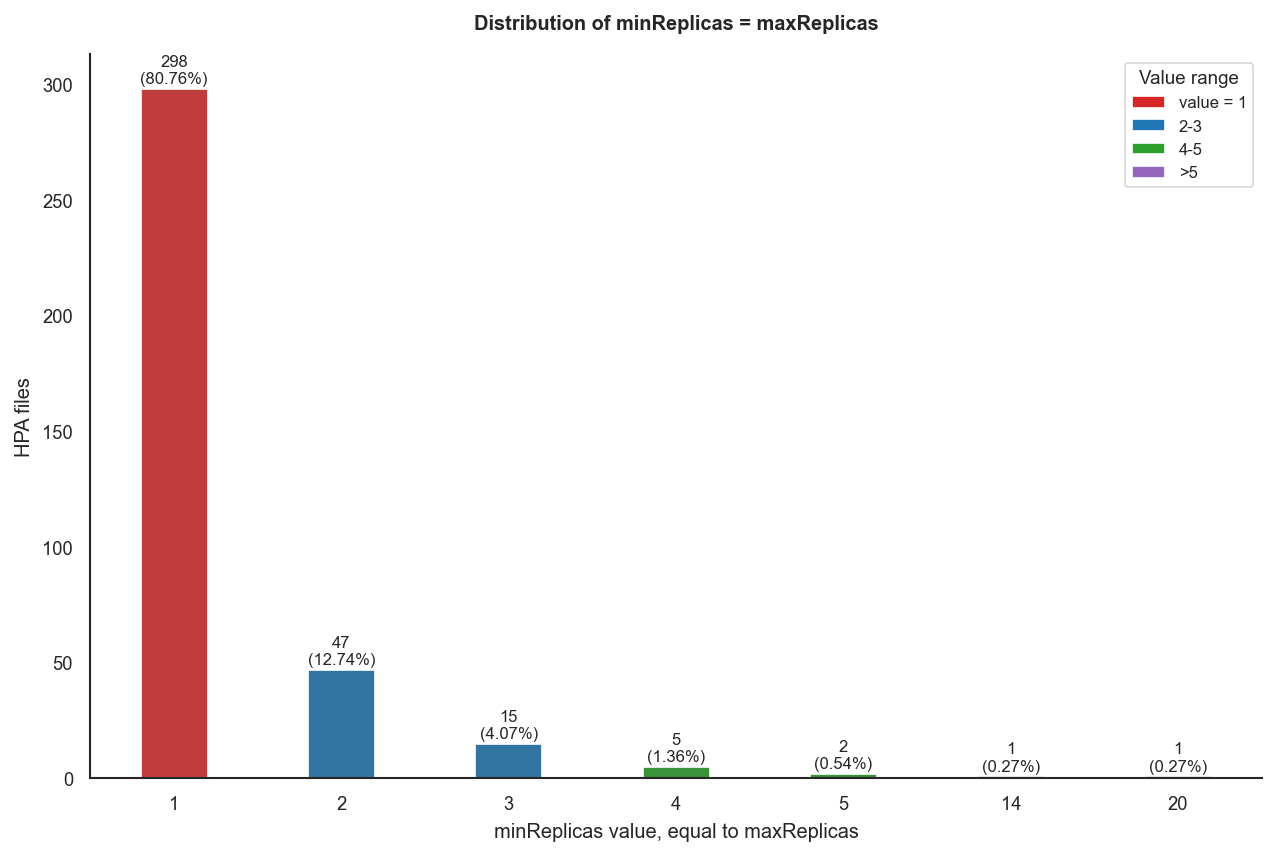

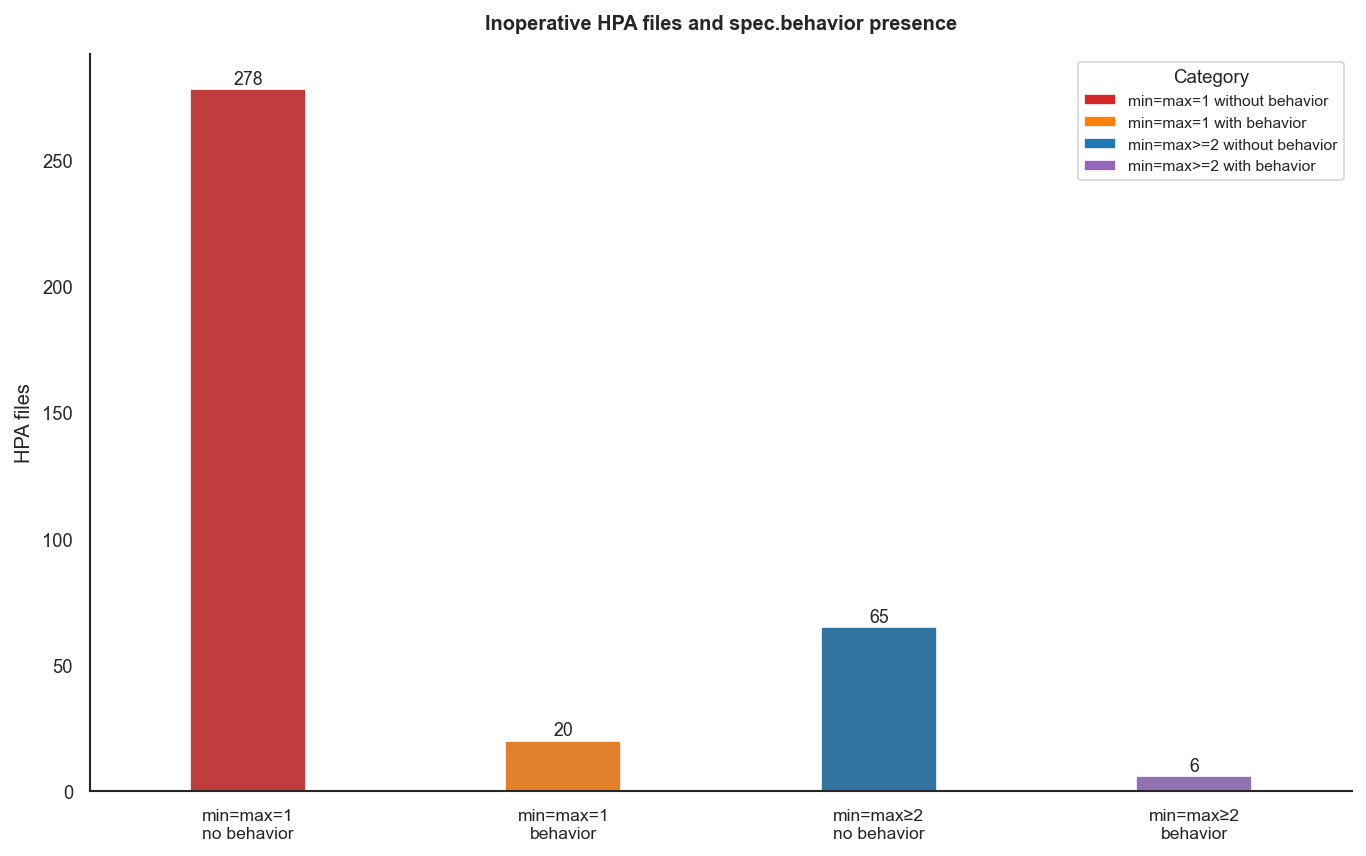

In [22]:
# ── Restored analytical prints from the original notebook ──
# ── Section 44-J: minReplicas = maxReplicas ──────────────────────────────────

from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

_inop44j = _pf[
    (_pf['min_r'].notna()) &
    (_pf['max_r'].notna()) &
    (_pf['min_r'] == _pf['max_r'])
].copy()

_N44J = len(_pf)
_inop_non1 = _inop44j[_inop44j['min_r'] != 1]

print(f"Total with min=max: {len(_inop44j):,} ({len(_inop44j)/_N44J*100:.2f}%)")
print(f"  min=max=1 (section 37): {(_inop44j['min_r'] == 1).sum():,}")
print(f"  min=max≠1 (this section): {len(_inop_non1):,}")
print()

print("Value distribution (min=max≠1):")
for v, cnt in _inop_non1['min_r'].value_counts().sort_index().items():
    pct = cnt / len(_inop_non1) * 100 if len(_inop_non1) else 0
    pct_total = cnt / _N44J * 100 if _N44J else 0
    print(f"  {int(v)}: {cnt:,} ({pct:.2f}% within min=max≠1; {pct_total:.2f}% of corpus)")

print()
print("With spec.behavior configured (min=max, any value):")
_beh_inop = int(_inop44j['has_beh'].sum())
_beh_non1 = int(_inop_non1['has_beh'].sum())
print(f"  Total: {_beh_inop:,} ({_beh_inop/len(_inop44j)*100:.2f}% within min=max)" if len(_inop44j) else "  Total: 0 (0.00% within min=max)")
print(f"  Of these, min=max≠1: {_beh_non1:,} ({_beh_non1/len(_inop_non1)*100:.2f}% within min=max≠1)" if len(_inop_non1) else "  Of these, min=max≠1: 0 (0.00% within min=max≠1)")

print()
print("min=max≠1: complete list:")
print(
    _inop_non1[
        ['Owner', 'Project', 'api_g', 'min_r', 'max_r', 'has_beh', 'scale_target']
    ].to_string(index=False)
)
# ── End of restored analytical prints ──

# ── Figure 44J: minReplicas = maxReplicas ───────────────────────────────────
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='white', context='paper')

inop = _pf[(_pf['min_r'].notna()) & (_pf['max_r'].notna()) & (_pf['min_r'] == _pf['max_r'])].copy()
inop_non1 = inop[inop['min_r'] != 1].copy()
vc = inop['min_r'].value_counts().sort_index().reset_index()
vc.columns = ['Value', 'Files']
vc['Share within min=max (%)'] = vc['Files'] / len(inop) * 100 if len(inop) else 0
cats = pd.DataFrame({
    'Category': ['min=max=1 without behavior', 'min=max=1 with behavior', 'min=max>=2 without behavior', 'min=max>=2 with behavior'],
    'Files': [((inop['min_r'] == 1) & (~inop['has_beh'])).sum(), ((inop['min_r'] == 1) & (inop['has_beh'])).sum(), ((inop['min_r'] != 1) & (~inop['has_beh'])).sum(), ((inop['min_r'] != 1) & (inop['has_beh'])).sum()]
})

# Figure 44JA
fig, ax = plt.subplots(figsize=(8.6, 5.8))
def _col(v): return '#d62728' if v == 1 else '#1f77b4' if v <= 3 else '#2ca02c' if v <= 5 else '#9467bd'
colors = [_col(v) for v in vc['Value']]
sns.barplot(data=vc, x=vc['Value'].astype(int).astype(str), y='Files', hue=vc['Value'].astype(str), palette=colors, dodge=False, legend=False, errorbar=None, ax=ax)
for patch in ax.patches:
    w=patch.get_width(); c=patch.get_x()+w/2; new_w=w*0.50
    patch.set_width(new_w); patch.set_x(c-new_w/2)
for i,row in enumerate(vc.itertuples(index=False)):
    ax.text(i, row.Files+1, f'{row.Files:,}\n({row._2:.2f}%)', ha='center', va='bottom', fontsize=8.0)
ax.set_xlabel('minReplicas value, equal to maxReplicas')
ax.set_ylabel('HPA files')
ax.set_title('Distribution of minReplicas = maxReplicas', pad=12)
ax.legend(handles=[Patch(facecolor='#d62728', label='value = 1'), Patch(facecolor='#1f77b4', label='2-3'), Patch(facecolor='#2ca02c', label='4-5'), Patch(facecolor='#9467bd', label='>5')], title='Value range', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig44j_a_min_eq_max_distribution.pdf')
plt.show()

# Figure 44JB
fig, ax = plt.subplots(figsize=(9.2, 5.8))
cat_colors = ['#d62728', '#ff7f0e', '#1f77b4', '#9467bd']
sns.barplot(data=cats, x='Category', y='Files', hue='Category', palette=dict(zip(cats['Category'], cat_colors)), dodge=False, legend=False, errorbar=None, ax=ax)
for patch in ax.patches:
    w=patch.get_width(); c=patch.get_x()+w/2; new_w=w*0.46
    patch.set_width(new_w); patch.set_x(c-new_w/2)
for i,row in enumerate(cats.itertuples(index=False)):
    ax.text(i, row.Files+0.5, f'{row.Files:,}', ha='center', va='bottom', fontsize=8.5)
ax.set_xlabel('')
ax.set_ylabel('HPA files')
ax.set_title('Inoperative HPA files and spec.behavior presence', pad=12)
ax.set_xticklabels(['min=max=1\nno behavior', 'min=max=1\nbehavior', 'min=max≥2\nno behavior', 'min=max≥2\nbehavior'], fontsize=8.4)
ax.legend(handles=[Patch(facecolor=cat_colors[i], edgecolor='white', label=cats['Category'][i]) for i in range(len(cats))], title='Category', frameon=True, loc='upper right', fontsize=7.5, title_fontsize=9.0)
sp(ax); ax.grid(False)
plt.tight_layout()
savefig('fig44j_b_min_eq_max_behavior.pdf')
plt.show()


## 13. Association between `minReplicas >= 2` and `spec.behavior`

This section tests whether files under `autoscaling/v2` or `autoscaling/v2beta2` with `minReplicas >= 2` configure `spec.behavior` more often than files with `minReplicas < 2`.

The next cell prints the rates per `minReplicas` value, computes the Fisher test, and produces separate figures to support the interpretation. The values should be read from the cell output, so that they stay consistent with new runs over the corpus.


H11, min>=2 and spec.behavior, v2/v2beta2:
  n=7,351 | Fisher OR=2.735, p=1.485e-86
Behavior rate by minReplicas value, v2/v2beta2:
  min=1: 3,254 files | behavior=22.34%
  min=2: 2,626 files | behavior=38.65%
  min=3: 1,262 files | behavior=55.86%
  min=4:    45 files | behavior=26.67%
  min=5:    84 files | behavior=48.81%
  min>=5:   155 files | behavior=49.68%
  v2beta2: min<2=11.54%, min>=2=11.29%, OR=0.98, p=1.000e+00
  v2: min<2=24.82%, min>=2=47.55%, OR=2.75, p=2.907e-78
Maturity quadrants, v2/v2beta2:
  HA + Behavior:       1,809 (24.61%)
  HA without behavior: 2,279 (31.00%)
  Behavior without HA:   734 (9.99%)
  Neither HA nor Beh.: 2,529 (34.40%)


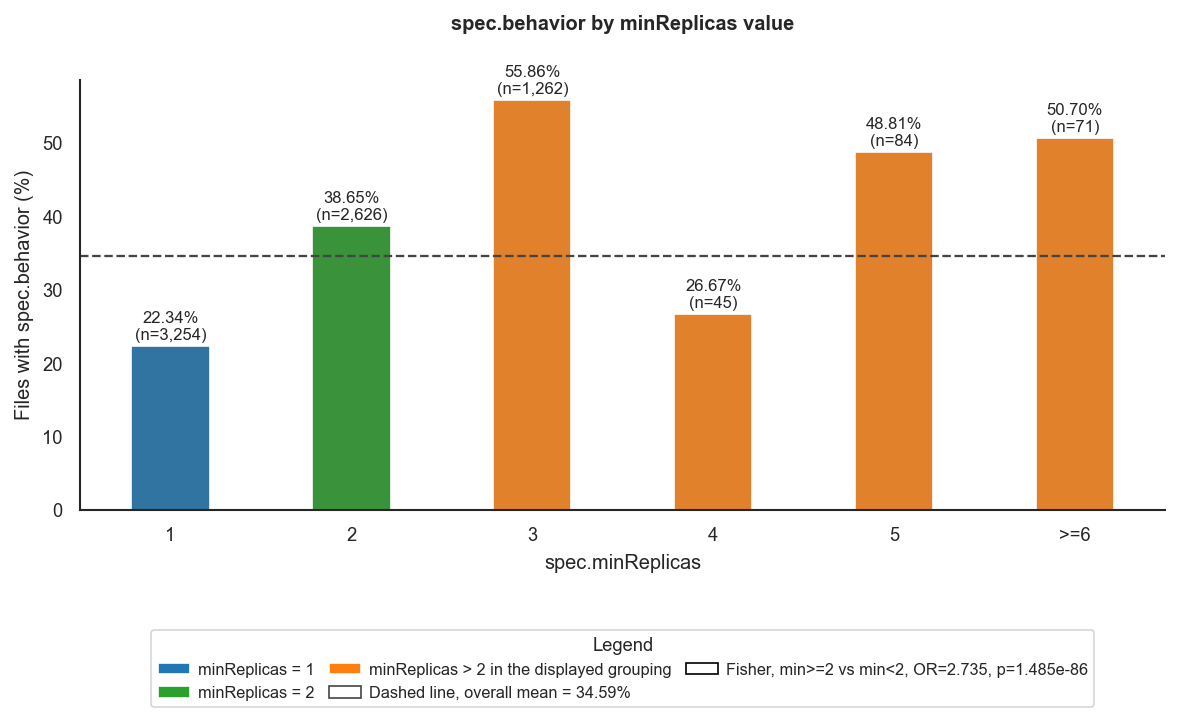

Figure H11A displayed and saved as PDF.


In [23]:

# ── H11: operational maturity, split PDF figures ────────────────────────────
pf_v2_h11 = _pf[_pf['api_g'].isin(['v2', 'v2beta2']) & _pf['min_r'].notna()].copy()
ct_h11 = pd.crosstab(pf_v2_h11['min_r'] >= 2, pf_v2_h11['has_beh'])
odds_h11, p_h11 = fisher_exact(ct_h11.values)

print('H11, min>=2 and spec.behavior, v2/v2beta2:')
print(f'  n={len(pf_v2_h11):,} | Fisher OR={odds_h11:.3f}, p={p_h11:.3e}')
print('Behavior rate by minReplicas value, v2/v2beta2:')
for val in [0,1,2,3,4,5]:
    sub = pf_v2_h11[pf_v2_h11['min_r'] == val]
    if len(sub) >= 10:
        print(f'  min={val}: {len(sub):>5,} files | behavior={sub["has_beh"].mean()*100:.2f}%')
sub_5p = pf_v2_h11[pf_v2_h11['min_r'] >= 5]
if len(sub_5p) >= 10:
    print(f'  min>=5: {len(sub_5p):>5,} files | behavior={sub_5p["has_beh"].mean()*100:.2f}%')

api_stats_h11 = {}
for api in ['v2beta2', 'v2']:
    sub_api = _pf[(_pf['api_g'] == api) & _pf['min_r'].notna()]
    ct = pd.crosstab(sub_api['min_r'] >= 2, sub_api['has_beh'])
    if ct.shape == (2,2):
        odds_a, p_a = fisher_exact(ct.values)
        api_stats_h11[api] = {
            'pct_lt2': sub_api[sub_api['min_r'] < 2]['has_beh'].mean()*100,
            'pct_ge2': sub_api[sub_api['min_r'] >= 2]['has_beh'].mean()*100,
            'or': odds_a,
            'p': p_a,
            'n': len(sub_api),
        }
        print(f'  {api}: min<2={api_stats_h11[api]["pct_lt2"]:.2f}%, min>=2={api_stats_h11[api]["pct_ge2"]:.2f}%, OR={odds_a:.2f}, p={p_a:.3e}')

both = int(((pf_v2_h11['min_r'] >= 2) & pf_v2_h11['has_beh']).sum())
minonly = int(((pf_v2_h11['min_r'] >= 2) & ~pf_v2_h11['has_beh']).sum())
behonly = int(((pf_v2_h11['min_r'] < 2) & pf_v2_h11['has_beh']).sum())
neither = int(((pf_v2_h11['min_r'] < 2) & ~pf_v2_h11['has_beh']).sum())
n_h11 = len(pf_v2_h11)
print('Maturity quadrants, v2/v2beta2:')
print(f'  HA + Behavior:       {both:>5,} ({both/n_h11*100:.2f}%)')
print(f'  HA without behavior: {minonly:>5,} ({minonly/n_h11*100:.2f}%)')
print(f'  Behavior without HA: {behonly:>5,} ({behonly/n_h11*100:.2f}%)')
print(f'  Neither HA nor Beh.: {neither:>5,} ({neither/n_h11*100:.2f}%)')

# H11A
rows = []
for val in [1,2,3,4,5,'>=6']:
    sub = pf_v2_h11[pf_v2_h11['min_r'] >= 6] if val == '>=6' else pf_v2_h11[pf_v2_h11['min_r'] == val]
    if len(sub) >= 10:
        rows.append({'minReplicas': str(val), 'Share (%)': sub['has_beh'].mean()*100, 'Files': len(sub)})
h11a_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8.0,5.2))
colors = ['#1f77b4' if x == '1' else '#2ca02c' if x == '2' else '#ff7f0e' for x in h11a_df['minReplicas']]
sns.barplot(data=h11a_df, x='minReplicas', y='Share (%)', hue='minReplicas', palette=colors, legend=False, errorbar=None, ax=ax)
narrow_bars(ax, scale=0.54, orientation='v')
for i,row in enumerate(h11a_df.itertuples(index=False)):
    ax.text(i, row[1]+0.45, f'{row[1]:.2f}%\n(n={row.Files:,})', ha='center', va='bottom', fontsize=8.0)
mean_h11 = pf_v2_h11['has_beh'].mean()*100
ax.axhline(mean_h11, color='#444444', linestyle='--', linewidth=1.1)
ax.set_xlabel('spec.minReplicas')
ax.set_ylabel('Files with spec.behavior (%)')
ax.set_title('spec.behavior by minReplicas value', pad=24)
ax.legend(handles=[Patch(facecolor='#1f77b4', label='minReplicas = 1'), Patch(facecolor='#2ca02c', label='minReplicas = 2'), Patch(facecolor='#ff7f0e', label='minReplicas > 2 in the displayed grouping'), Patch(facecolor='white', edgecolor='#444444', label=f'Dashed line, overall mean = {mean_h11:.2f}%'), Patch(facecolor='white', edgecolor='black', label=f'Fisher, min>=2 vs min<2, OR={odds_h11:.3f}, p={p_h11:.3e}')], title='Legend', frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.26), ncol=3, fontsize=7.8, title_fontsize=8.8, columnspacing=0.9, handletextpad=0.45)
sp(ax); ax.grid(False)
save_and_show('fig_h11a_behavior_by_minreplicas.pdf')
print('Figure H11A displayed and saved as PDF.')


## 14. Configuration profiles: feature combinations

Each HPA file is described by a binary vector that records the presence of four feature groups:

1. `memory`, the use of `Resource/memory`;
2. `behavior`, the presence of `spec.behavior`;
3. `HA`, meaning `minReplicas >= 2`;
4. `custom`, the use of `Pods`, `External`, `Object` or `ContainerResource` metrics.

The section identifies the most frequent profiles, the dominant version in each profile, and the average depth of `spec.behavior` where applicable. The cell rebuilds `_pf` locally when needed, which allows running this section even after a runtime restart.


Configuration profiles, decreasing frequency:
Code   Description                               n        %  Dominant version
----------------------------------------------------------------------------------
  0000   Basic, cpu, min=1, no behavior       3,341   34.22%  v2 (45.08%)
  0001   Basic HA, cpu, min>=2                1,890   19.36%  v2 (55.03%)
  1101   Behavior + memory + HA               1,249   12.79%  v2 (98.96%)
  0101   Memory + HA                          1,015   10.40%  v2 (83.15%)
  0100   Memory added                           436    4.47%  v2 (73.17%)
  1000   Behavior without extras                345    3.53%  v2 (86.38%)
  1111   Complete, all dimensions               331    3.39%  v2 (100.00%)
  1100   Behavior + memory                      311    3.19%  v2 (95.50%)
  0010   Custom metrics                         265    2.71%  v2 (52.83%)
  1001   Behavior + HA                          201    2.06%  v2 (87.06%)
  0110   Memory + custom                        125 

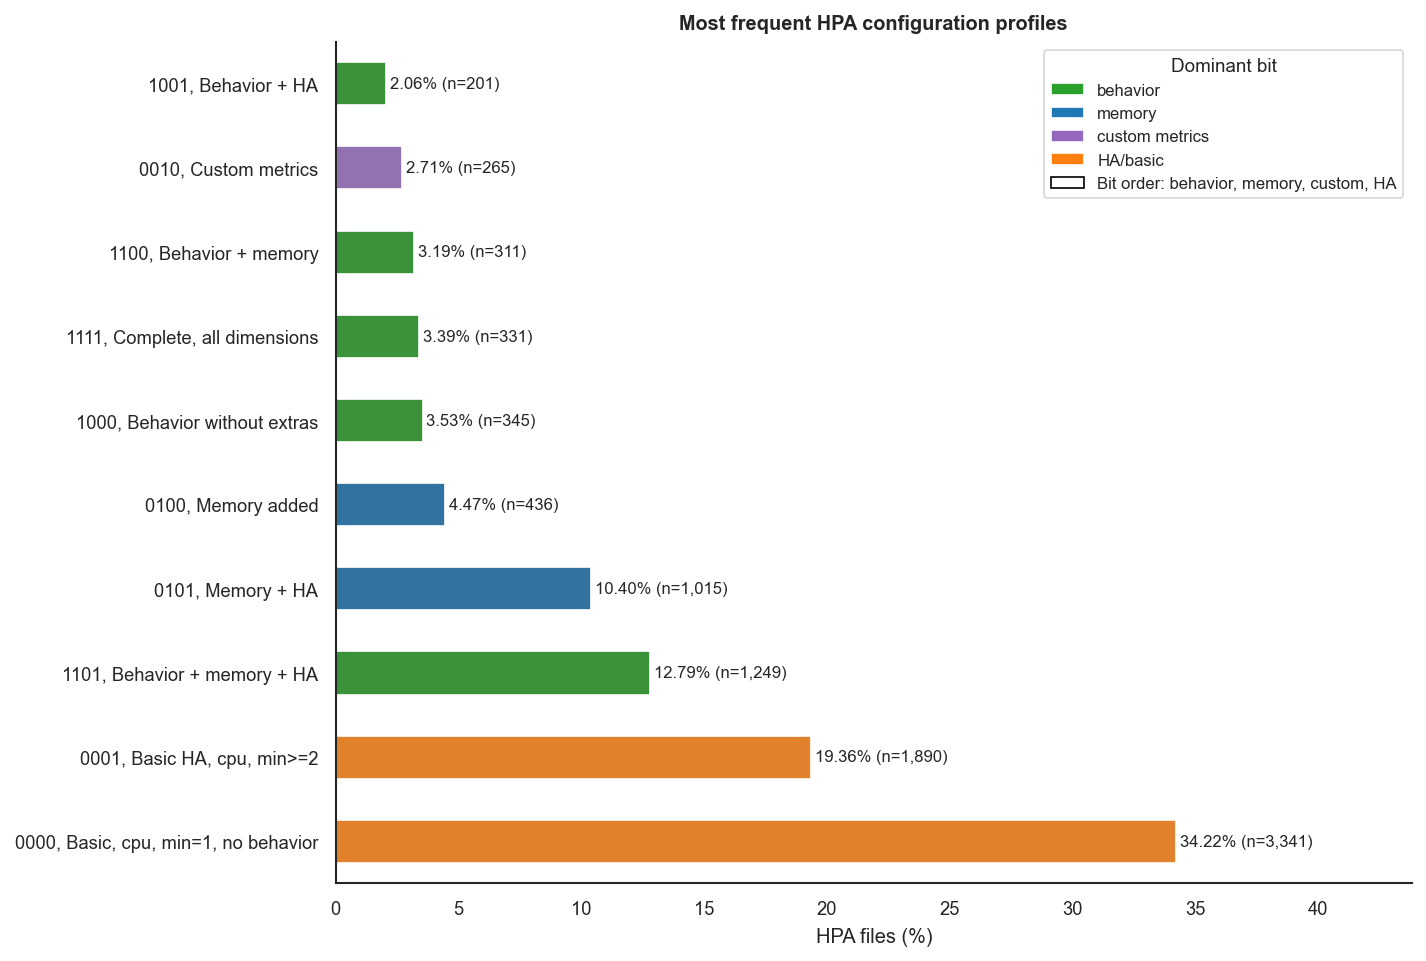

Figure 47A displayed and saved as PDF.


In [24]:
# ── Section 51: configuration profiles, split PDF figures ───────────────────
# Helper fallback for standalone execution of this section
if 'narrow_bars' not in globals():
    def narrow_bars(ax, scale=0.62, orientation='v'):
        for patch in ax.patches:
            if orientation == 'v':
                w = patch.get_width(); cx = patch.get_x() + w / 2
                nw = w * scale
                patch.set_width(nw); patch.set_x(cx - nw / 2)
            else:
                h = patch.get_height(); cy = patch.get_y() + h / 2
                nh = h * scale
                patch.set_height(nh); patch.set_y(cy - nh / 2)
if 'save_and_show' not in globals():
    def save_and_show(name):
        plt.tight_layout()
        savefig(name)
        plt.show()

from collections import Counter
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# Rebuild _pf if this section is executed standalone after a runtime restart.
if '_pf' not in globals():
    def _as_set_from_series(series):
        return set(str(v).strip().lower() for v in series.dropna().tolist() if str(v).strip())

    _p4_profiles = pd.read_csv(DATA_DIR / 'phase4_latest.csv')
    _pf = _p4_profiles.groupby(['Owner', 'Project', 'File Path']).agg(
        api_g=('apiVersion', lambda s: str(s.dropna().iloc[0]).replace('autoscaling/', '').lower() if len(s.dropna()) else 'unknown'),
        has_beh=('Has Behavior', lambda s: bool(pd.Series(s).fillna(False).astype(bool).any())),
        min_r=('MinReplicas', lambda s: pd.to_numeric(s, errors='coerce').dropna().iloc[0] if len(pd.to_numeric(s, errors='coerce').dropna()) else np.nan),
        max_r=('MaxReplicas', lambda s: pd.to_numeric(s, errors='coerce').dropna().iloc[0] if len(pd.to_numeric(s, errors='coerce').dropna()) else np.nan),
        tipos_set=('Metric Type', _as_set_from_series),
        nomes_set=('metric_name', _as_set_from_series),
    ).reset_index()
    _pf['n_tipos'] = _pf['tipos_set'].apply(len)
    if (DATA_DIR / 'phase3_file_commits_latest.csv').exists():
        _p3c_profiles = pd.read_csv(DATA_DIR / 'phase3_file_commits_latest.csv')
        if 'file_last_commit' in _p3c_profiles.columns:
            _p3c_profiles['commit_year'] = pd.to_datetime(_p3c_profiles['file_last_commit'], errors='coerce', utc=True).dt.year
            _pf = _pf.merge(_p3c_profiles[['Owner','Project','File Path','commit_year']], on=['Owner','Project','File Path'], how='left')
    if (DATA_DIR / 'hpa_repo_aggregated.csv').exists():
        _repos_profiles = pd.read_csv(DATA_DIR / 'hpa_repo_aggregated.csv')
        if 'repo_full_name' in _repos_profiles.columns:
            _pf['repo_full_name'] = _pf['Owner'] + '/' + _pf['Project']
            _cols = [c for c in ['repo_full_name','created_at','pushed_at','stargazers_count'] if c in _repos_profiles.columns]
            _pf = _pf.merge(_repos_profiles[_cols], on='repo_full_name', how='left')
    print(f'_pf rebuilt for standalone execution: {len(_pf):,} HPA files')

_pf['d_behavior'] = _pf['has_beh'].astype(int)
_pf['d_memory'] = _pf['nomes_set'].apply(lambda x: int('memory' in x))
_pf['d_custom'] = _pf['tipos_set'].apply(lambda x: int(bool(x & {'pods', 'external', 'object', 'containerresource'})))
_pf['d_ha'] = (_pf['min_r'].fillna(1) >= 2).astype(int)
_pf['profile'] = (_pf['d_behavior'].astype(str) + _pf['d_memory'].astype(str) + _pf['d_custom'].astype(str) + _pf['d_ha'].astype(str))

PROFILE_LABELS = {
    '0000': 'Basic, cpu, min=1, no behavior',
    '0001': 'Basic HA, cpu, min>=2',
    '0010': 'Custom metrics',
    '0011': 'Custom metrics + HA',
    '0100': 'Memory added',
    '0101': 'Memory + HA',
    '0110': 'Memory + custom',
    '0111': 'Memory + custom + HA',
    '1000': 'Behavior without extras',
    '1001': 'Behavior + HA',
    '1010': 'Behavior + custom',
    '1011': 'Behavior + custom + HA',
    '1100': 'Behavior + memory',
    '1101': 'Behavior + memory + HA',
    '1110': 'Behavior + memory + custom',
    '1111': 'Complete, all dimensions',
}

prof_counts = _pf['profile'].value_counts()
N = len(_pf)

print('Configuration profiles, decreasing frequency:')
print(f"{'Code':<6} {'Description':<35} {'n':>7}  {'%':>7}  {'Dominant version'}")
print('-' * 82)
for p, cnt in prof_counts.items():
    lbl = PROFILE_LABELS.get(p, p)
    pct = cnt / N * 100
    dom_api = _pf[_pf['profile'] == p]['api_g'].value_counts().index[0]
    dom_pct = _pf[_pf['profile'] == p]['api_g'].value_counts().iloc[0] / cnt * 100
    print(f"  {p}   {lbl:<35} {cnt:>6,}  {pct:>6.2f}%  {dom_api} ({dom_pct:.2f}%)")
print(f"\n16 possible profiles, {len(prof_counts)} observed in the corpus.")
n_rare = (prof_counts < 50).sum()
print(f'Rare profiles, n<50: {n_rare} out of {len(prof_counts)}')

# Figure 47A
top10 = prof_counts.head(10)
prof_df = pd.DataFrame({
    'Profile': top10.index,
    'Description': [PROFILE_LABELS.get(p, p) for p in top10.index],
    'Share (%)': top10.values / N * 100,
    'Files': top10.values,
})
prof_df['Label'] = prof_df.apply(lambda r: f"{r['Profile']}, {r['Description'][:32]}", axis=1)
prof_df['Dominant bit'] = prof_df['Profile'].apply(lambda p: 'behavior' if p[0] == '1' else 'memory' if p[1] == '1' else 'custom metrics' if p[2] == '1' else 'HA/basic')
palette_bits = {'behavior': '#2ca02c', 'memory': '#1f77b4', 'custom metrics': '#9467bd', 'HA/basic': '#ff7f0e'}
plot_df = prof_df.sort_values('Share (%)', ascending=True)
fig, ax = plt.subplots(figsize=(9.6, 6.5))
sns.barplot(data=plot_df, y='Label', x='Share (%)', hue='Dominant bit', palette=palette_bits, dodge=False, errorbar=None, ax=ax)
if ax.get_legend() is not None:
    ax.get_legend().remove()
narrow_bars(ax, scale=0.64, orientation='h')
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['Share (%)'] + 0.15, i, f"{row['Share (%)']:.2f}% (n={int(row['Files']):,})", va='center', fontsize=8.0)
ax.set_xlabel('HPA files (%)')
ax.set_ylabel('')
ax.set_title('Most frequent HPA configuration profiles')
ax.set_xlim(0, max(plot_df['Share (%)']) * 1.28)
ax.legend(handles=[Patch(facecolor=palette_bits[k], label=k) for k in palette_bits] + [Patch(facecolor='white', edgecolor='black', label='Bit order: behavior, memory, custom, HA')], title='Dominant bit', frameon=True, loc='upper right', fontsize=8.0, title_fontsize=9.0)
sp(ax); ax.grid(False)
save_and_show('fig_47a_configuration_profiles.pdf')
print('Figure 47A displayed and saved as PDF.')


## 15. Final check of the expected figures

This cell verifies whether the main figures of the minimal version were written to the output directory. It is a quick check before exporting the PDF files or sharing the notebook.


In [25]:

expected_figures = [
    'fig02_apiversion_distribution.pdf',
    'fig03_temporal_commit_year.pdf',
    'fig31_api_migration_lag.pdf',
    'fig_47a_configuration_profiles.pdf',
    'fig_h11a_behavior_by_minreplicas.pdf',
    'fig44j_a_min_eq_max_distribution.pdf',
    'fig44j_b_min_eq_max_behavior.pdf',
    'fig44g_a_cpu_low_threshold_distribution.pdf',
    'fig44g_b_cpu_low_threshold_maxreplicas.pdf',
]

print('Expected figures for sbes2026-hpa-old-version:')
missing = []
for name in expected_figures:
    path = FIG_DIR / name
    status = 'OK' if path.exists() else 'missing'
    print(f'  {name:<48} {status}')
    if not path.exists():
        missing.append(name)

if missing:
    raise FileNotFoundError('Missing expected figures: ' + ', '.join(missing))
print('\nAll expected old-version figures were generated.')


Expected figures for sbes2026-hpa-old-version:
  fig02_apiversion_distribution.pdf                OK
  fig03_temporal_commit_year.pdf                   OK
  fig31_api_migration_lag.pdf                      OK
  fig_47a_configuration_profiles.pdf               OK
  fig_h11a_behavior_by_minreplicas.pdf             OK
  fig44j_a_min_eq_max_distribution.pdf             OK
  fig44j_b_min_eq_max_behavior.pdf                 OK
  fig44g_a_cpu_low_threshold_distribution.pdf      OK
  fig44g_b_cpu_low_threshold_maxreplicas.pdf       OK

All expected old-version figures were generated.
